In [1]:
# ==========================================================
# 1. SETUP: LIBRARIES & HELPER FUNCTIONS
# ==========================================================
print("--- Installing Dependencies... ---")
!pip install lightgbm catboost shap plotly

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer

# Metrics
from sklearn.metrics import accuracy_score, f1_score, roc_curve, auc, confusion_matrix, classification_report

# Models
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

print(" Libraries Imported Successfully.")

# --- VISUALIZATION FUNCTION ---
def plot_confusion_matrix_grid(results_dict, combo_name):
    """Plots the Grid of Confusion Matrices for one dataset combination"""
    n_models = len(results_dict)
    cols = 3
    rows = (n_models // cols) + (1 if n_models % cols > 0 else 0)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i, (name, data) in enumerate(results_dict.items()):
        cm = confusion_matrix(data['y_true'], data['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                   xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
        axes[i].set_title(f"{name}\nAcc: {data['Accuracy']:.2f} | F1: {data['F1']:.2f}")
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')

    # Turn off empty plots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"Confusion Matrix Grid: {combo_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_error_analysis(df_results, combo_name):
    """Plots the Comparison of Errors (FN vs FP)"""
    # FIX: Updated column names to match the data generator
    error_df = df_results[["False Pos (FP)", "False Neg (FN)"]]

    error_df.plot(kind='bar', figsize=(12, 5), color=['orange', 'red'], width=0.8)
    plt.title(f"Error Analysis: {combo_name} (Lower is Better)", fontsize=14)
    plt.ylabel("Number of Patients")
    plt.xticks(rotation=45, ha='right')
    plt.legend(title="Error Type")
    plt.show()

--- Installing Dependencies... ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00
 Libraries Imported Successfully.


In [2]:
# ==========================================================
# 2. LOAD RAW DATA SOURCES (A, B, C, D)
# ==========================================================
print("--- Loading Raw Data ---")
cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

def load_clean(url):
    df = pd.read_csv(url, names=cols, na_values='?')
    df['target'] = (df['target'] > 0).astype(int)
    return df

# Load all 4
df_A = load_clean("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data")
df_B = load_clean("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data")
df_C = load_clean("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data")
df_D = load_clean("https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data")

# Dictionary to access them by letter
datasets = {"A": df_A, "B": df_B, "C": df_C, "D": df_D}

print(f"Loaded: A (Cleveland)={len(df_A)}, B (Hungary)={len(df_B)}, C (Swiss)={len(df_C)}, D (VA)={len(df_D)}")

--- Loading Raw Data ---
Loaded: A (Cleveland)=303, B (Hungary)=294, C (Swiss)=123, D (VA)=200


 STARTING EXPERIMENT ON 15 DATASET COMBINATIONS...

 RUNNING EXPERIMENT: DATASET [A]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:45:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: A (Samples: 303)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.836066,0.833333,26,3,7,25
Logistic Reg,0.852459,0.857143,25,4,5,27
KNN,0.852459,0.861538,24,5,4,28
SVM,0.901639,0.903226,27,2,4,28
Decision Tree,0.786885,0.786885,24,5,8,24
Random Forest,0.885246,0.885246,27,2,5,27
XGBoost,0.836066,0.838710,25,4,6,26
LightGBM,0.885246,0.885246,27,2,5,27
CatBoost,0.852459,0.852459,26,3,6,26



--- Confusion Matrix Grid (A) ---


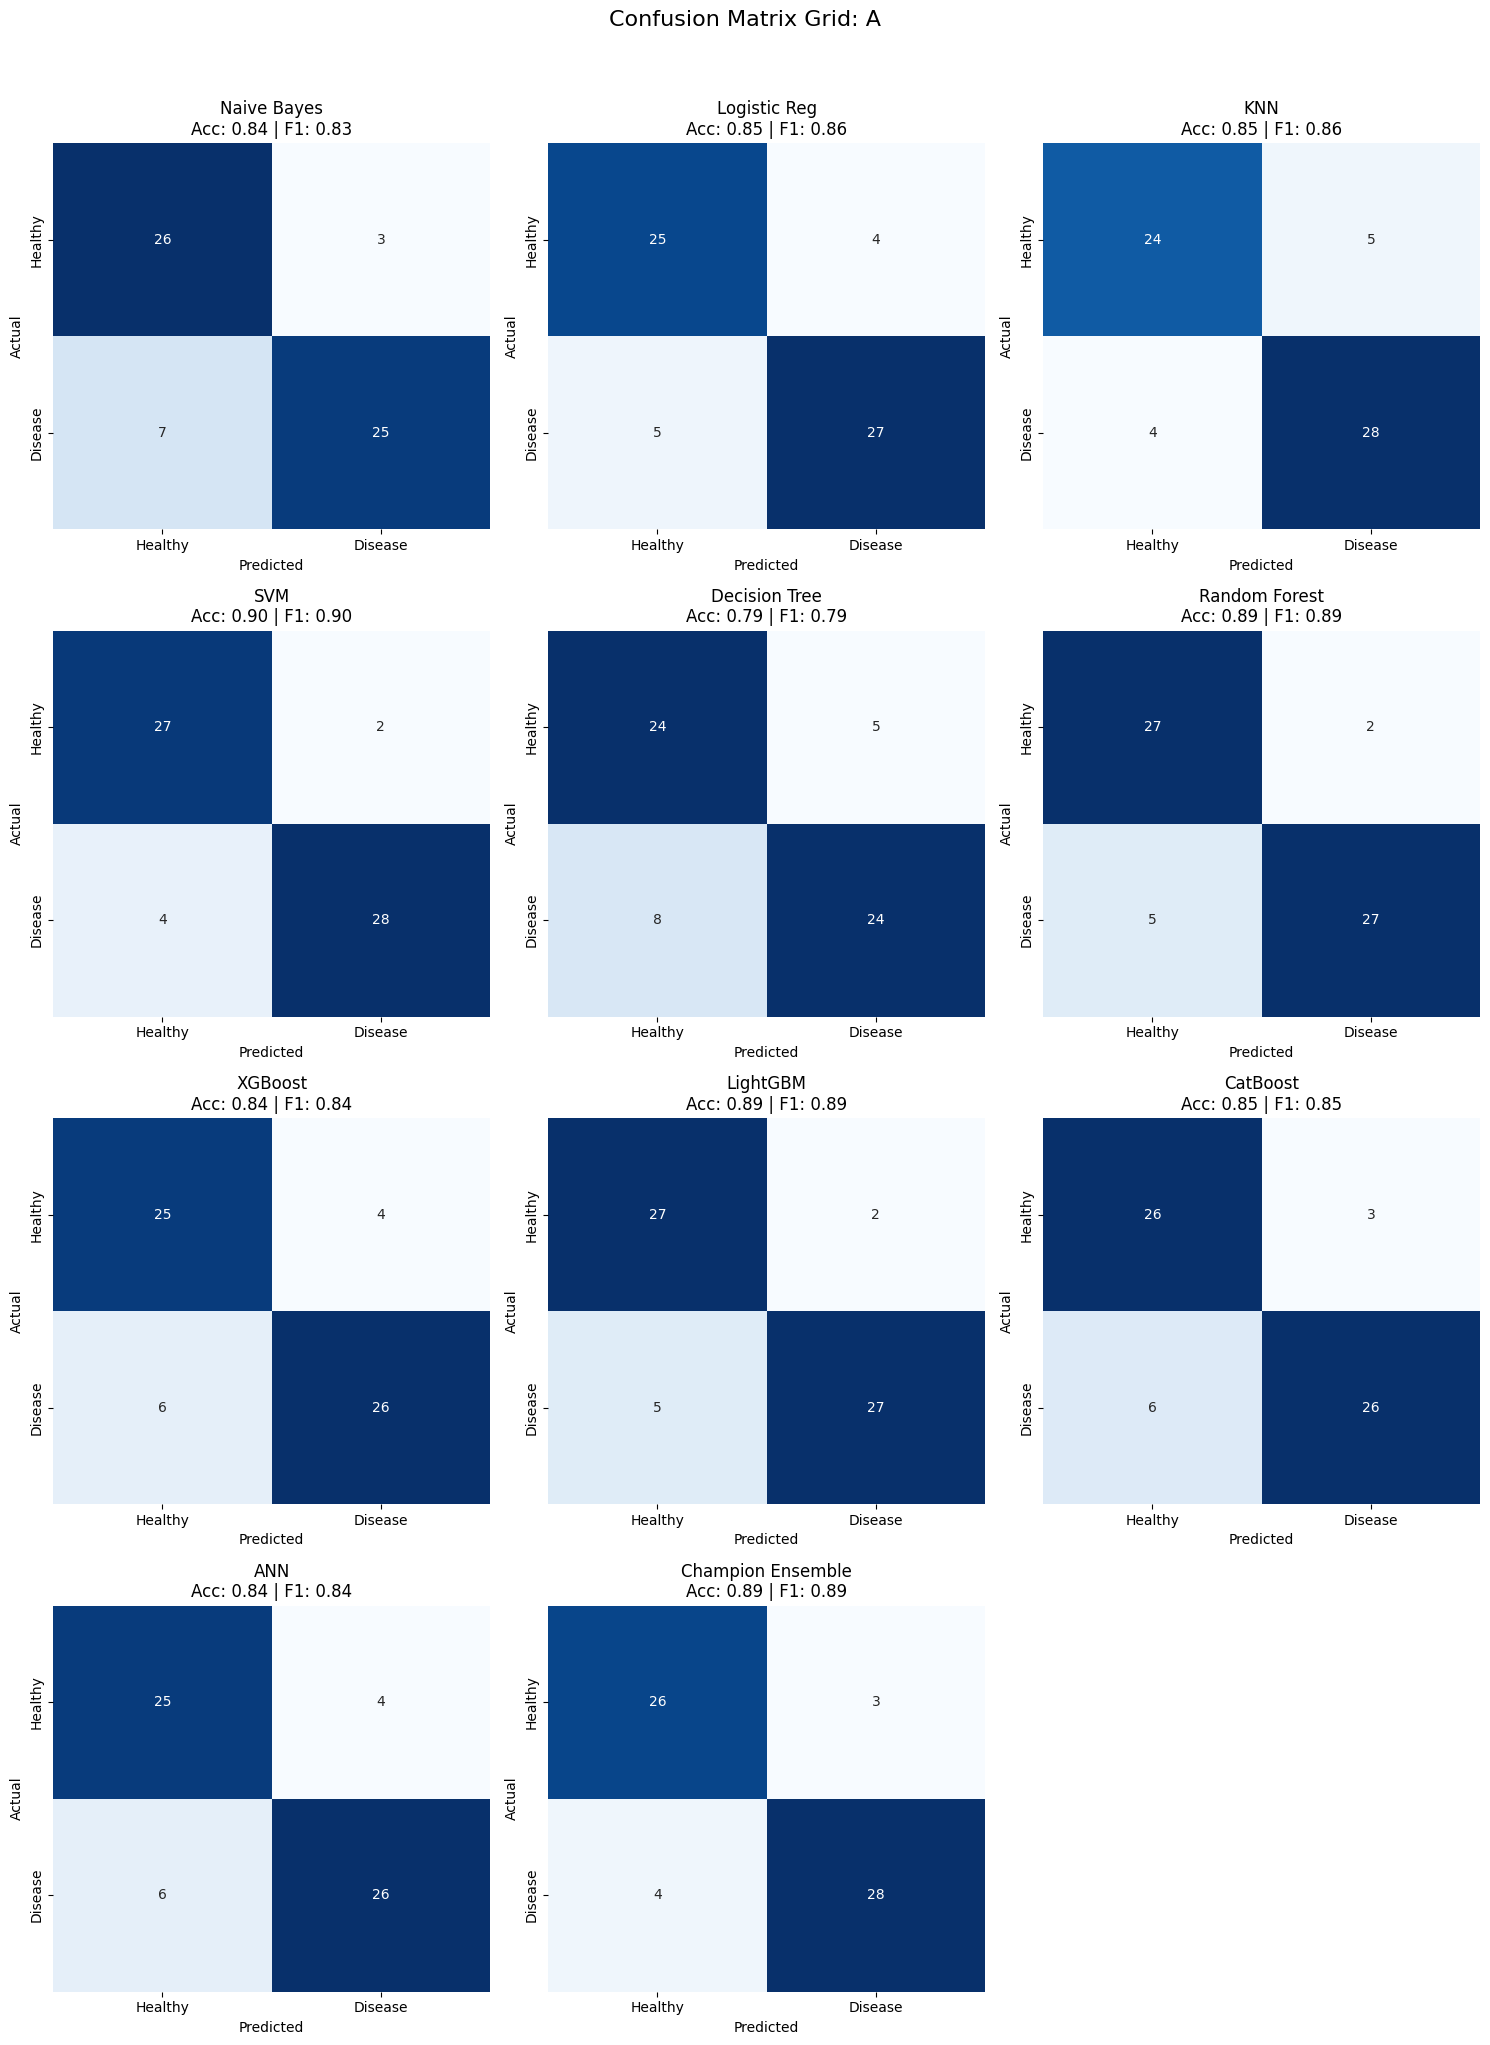


--- Error Analysis (A) ---


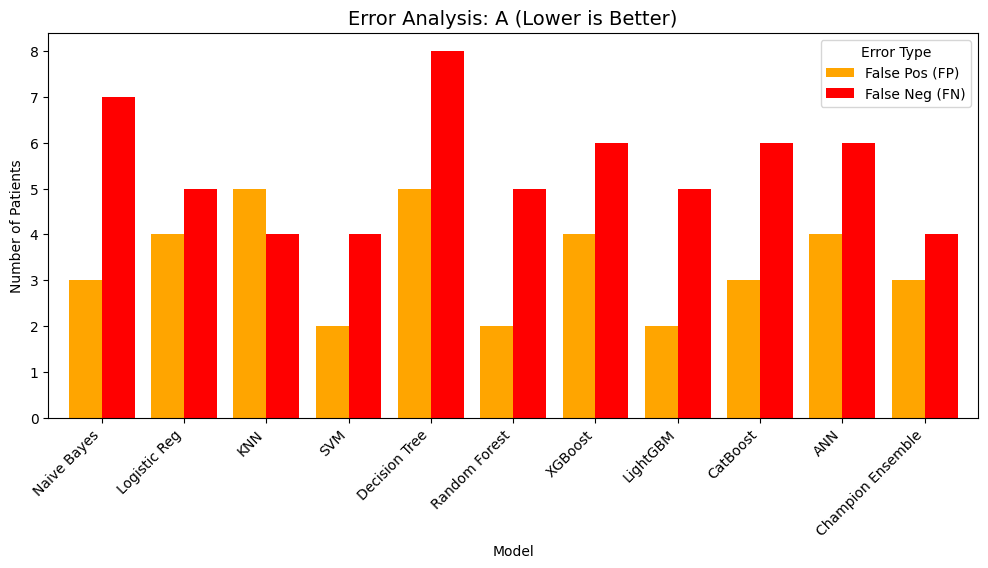




 RUNNING EXPERIMENT: DATASET [B]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:46:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: B (Samples: 294)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.864407,0.826087,32,6,2,19
Logistic Reg,0.847458,0.800000,32,6,3,18
KNN,0.813559,0.744186,32,6,5,16
SVM,0.864407,0.800000,35,3,5,16
Decision Tree,0.796610,0.727273,31,7,5,16
Random Forest,0.847458,0.790698,33,5,4,17
XGBoost,0.796610,0.714286,32,6,6,15
LightGBM,0.830508,0.761905,33,5,5,16
CatBoost,0.830508,0.761905,33,5,5,16



--- Confusion Matrix Grid (B) ---


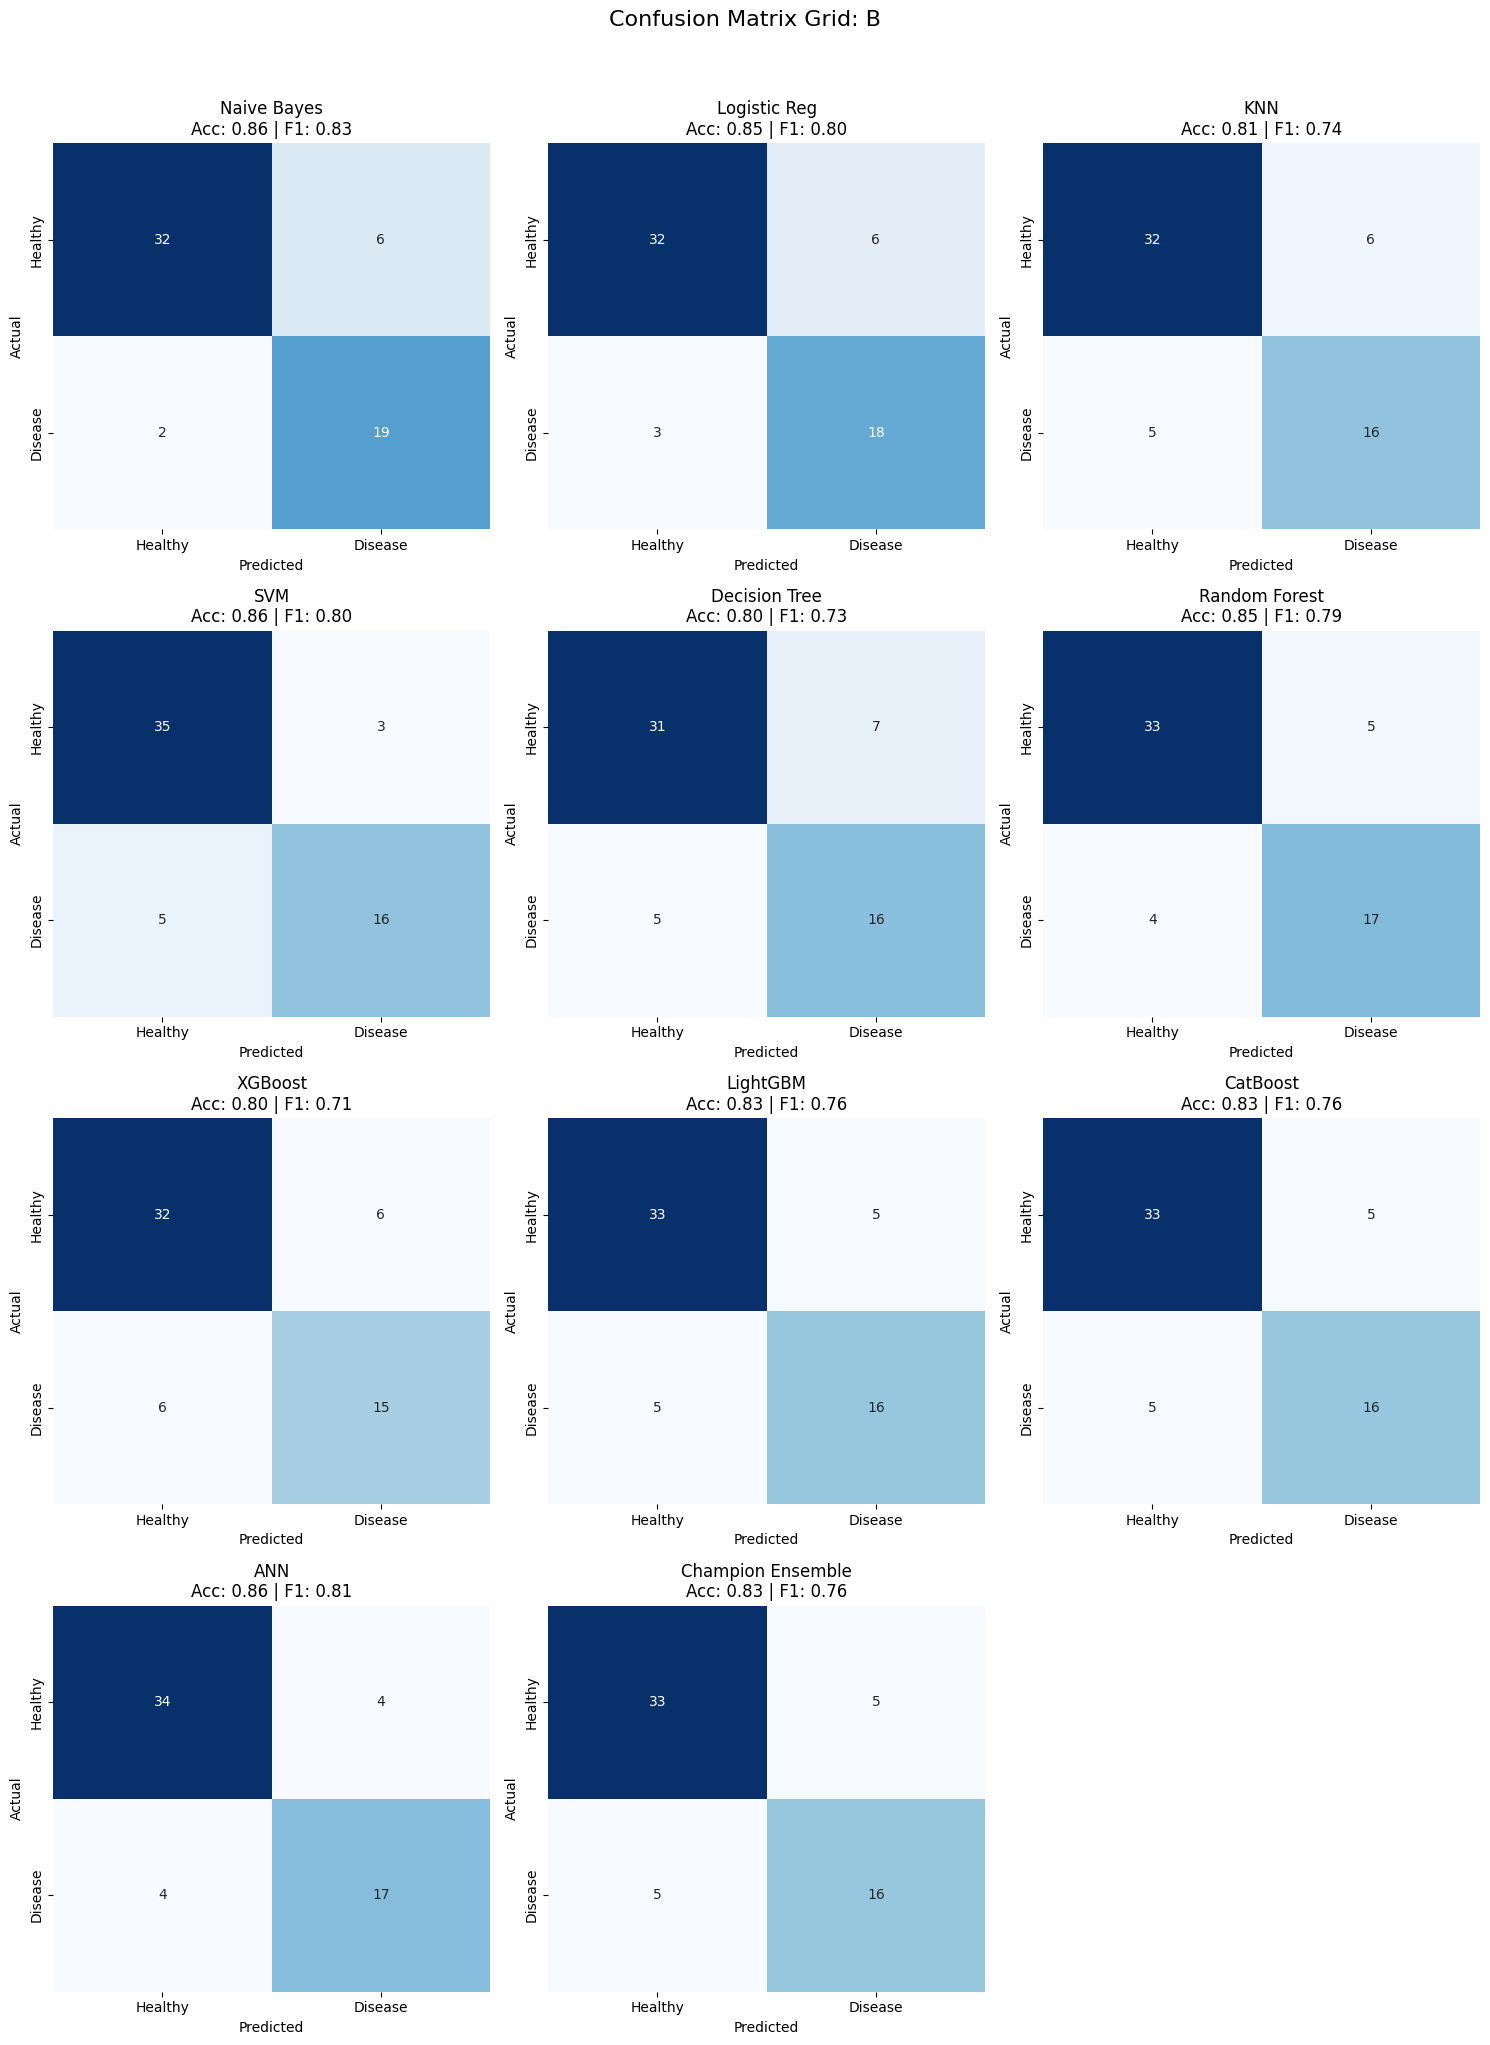


--- Error Analysis (B) ---


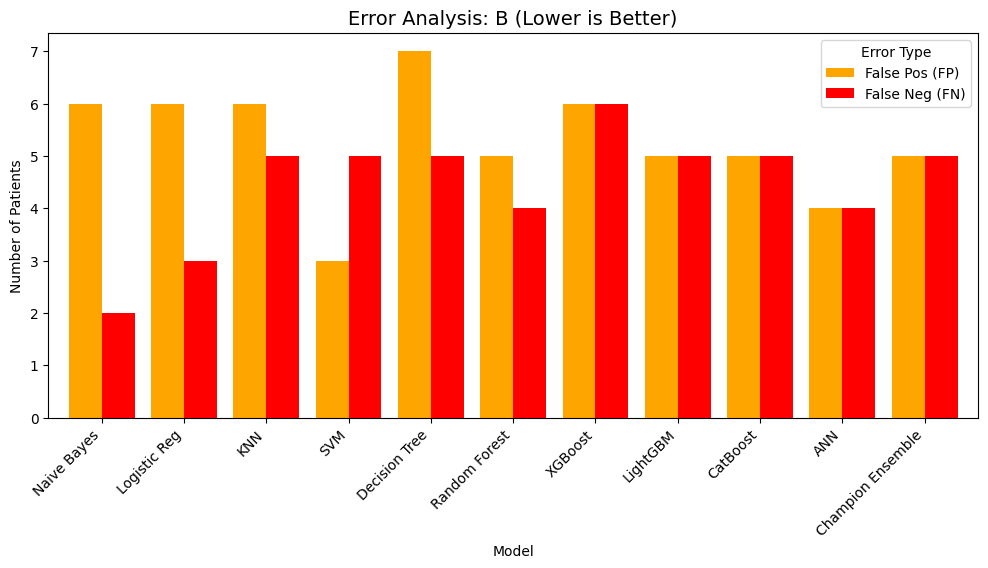




 RUNNING EXPERIMENT: DATASET [C]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:46:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: C (Samples: 123)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.440000,0.588235,1,1,13,10
Logistic Reg,0.880000,0.936170,0,2,1,22
KNN,0.920000,0.958333,0,2,0,23
SVM,0.920000,0.958333,0,2,0,23
Decision Tree,0.760000,0.863636,0,2,4,19
Random Forest,0.920000,0.958333,0,2,0,23
XGBoost,0.880000,0.936170,0,2,1,22
LightGBM,0.920000,0.958333,0,2,0,23
CatBoost,0.880000,0.936170,0,2,1,22



--- Confusion Matrix Grid (C) ---


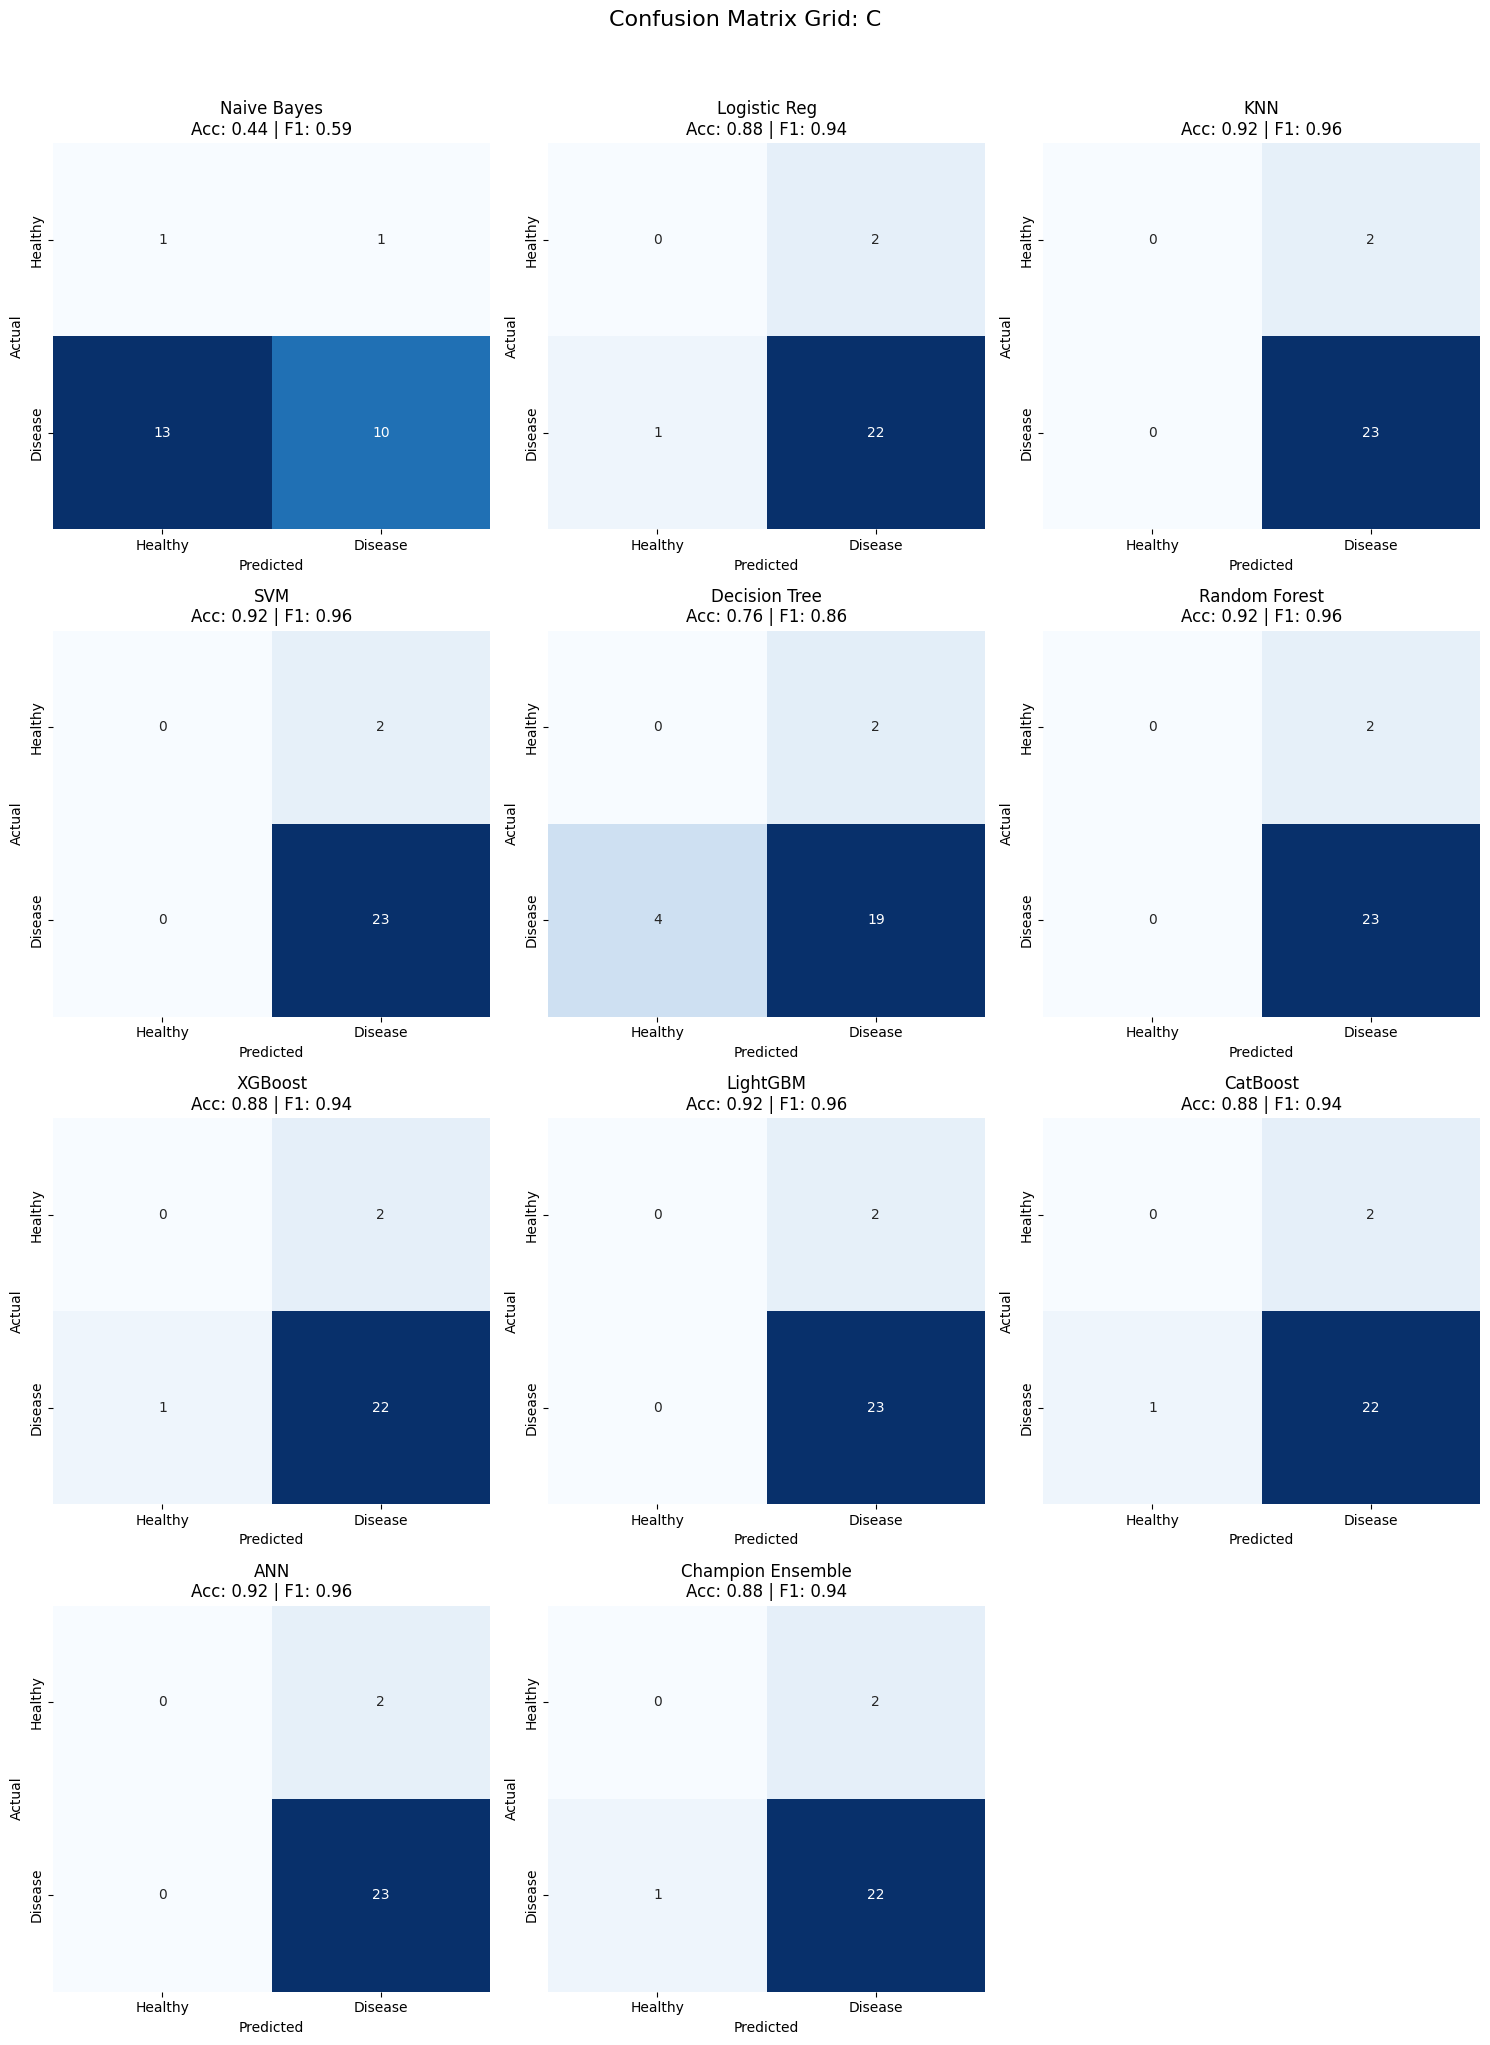


--- Error Analysis (C) ---


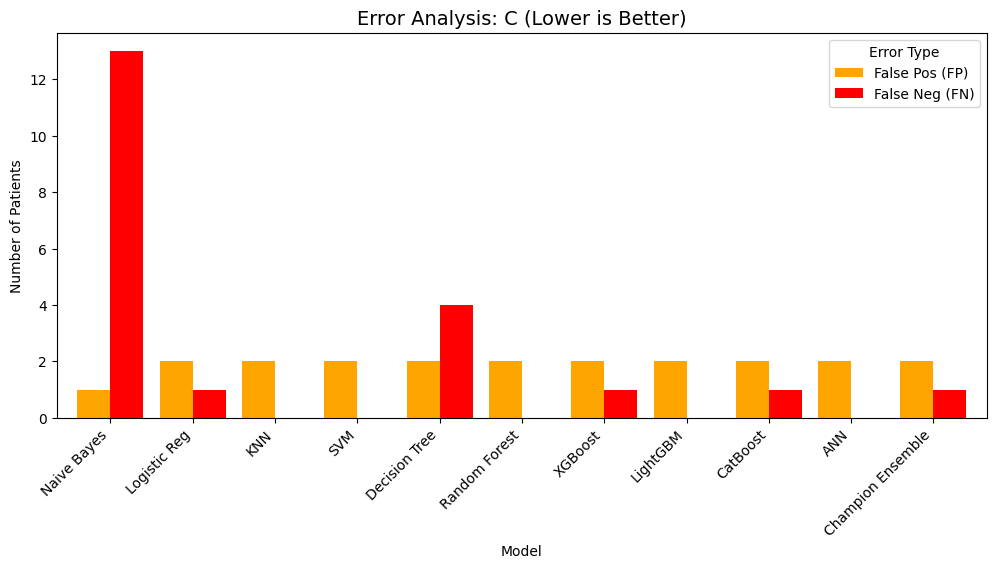




 RUNNING EXPERIMENT: DATASET [D]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:46:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: D (Samples: 200)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.775000,0.861538,3,5,4,28
Logistic Reg,0.800000,0.878788,3,5,3,29
KNN,0.775000,0.865672,2,6,3,29
SVM,0.775000,0.869565,1,7,2,30
Decision Tree,0.500000,0.655172,1,7,13,19
Random Forest,0.775000,0.869565,1,7,2,30
XGBoost,0.725000,0.835821,1,7,4,28
LightGBM,0.750000,0.848485,2,6,4,28
CatBoost,0.750000,0.852941,1,7,3,29



--- Confusion Matrix Grid (D) ---


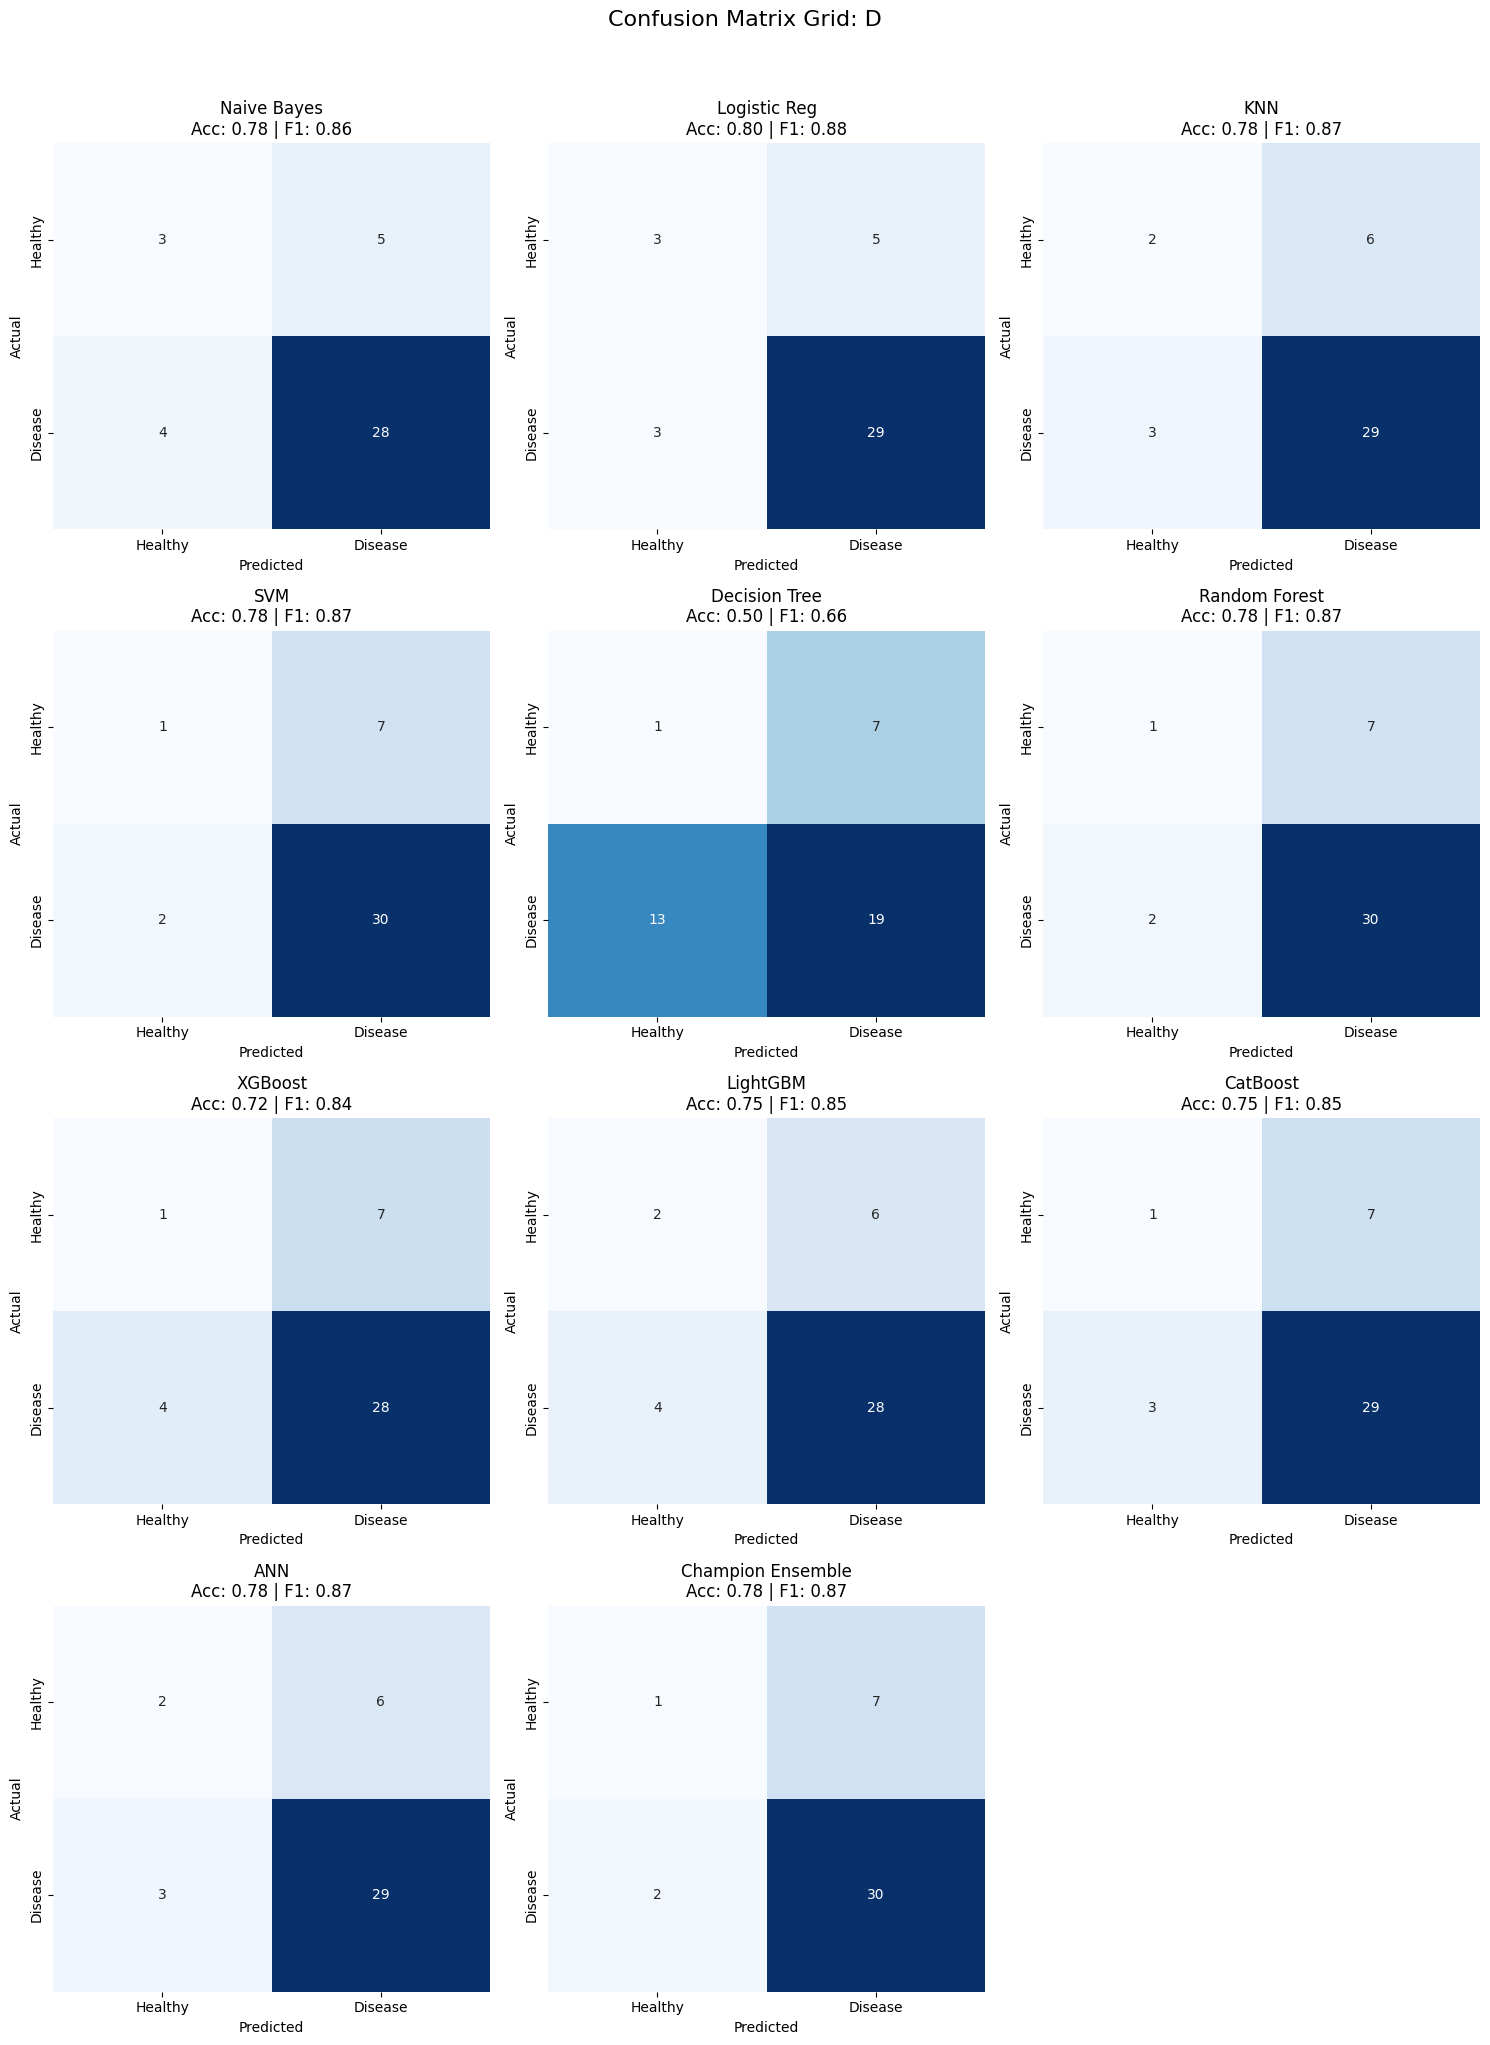


--- Error Analysis (D) ---


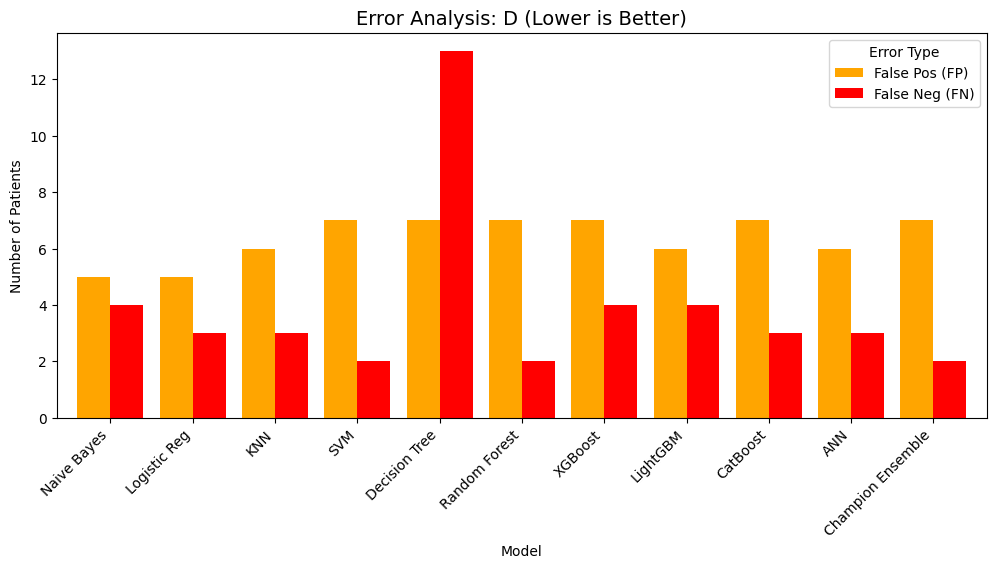




 RUNNING EXPERIMENT: DATASET [A+B]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:46:46] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: A+B (Samples: 597)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.858333,0.828283,62,7,10,41
Logistic Reg,0.850000,0.808511,64,5,13,38
KNN,0.833333,0.791667,62,7,13,38
SVM,0.841667,0.800000,63,6,13,38
Decision Tree,0.775000,0.727273,57,12,15,36
Random Forest,0.850000,0.808511,64,5,13,38
XGBoost,0.791667,0.736842,60,9,16,35
LightGBM,0.825000,0.774194,63,6,15,36
CatBoost,0.841667,0.804124,62,7,12,39



--- Confusion Matrix Grid (A+B) ---


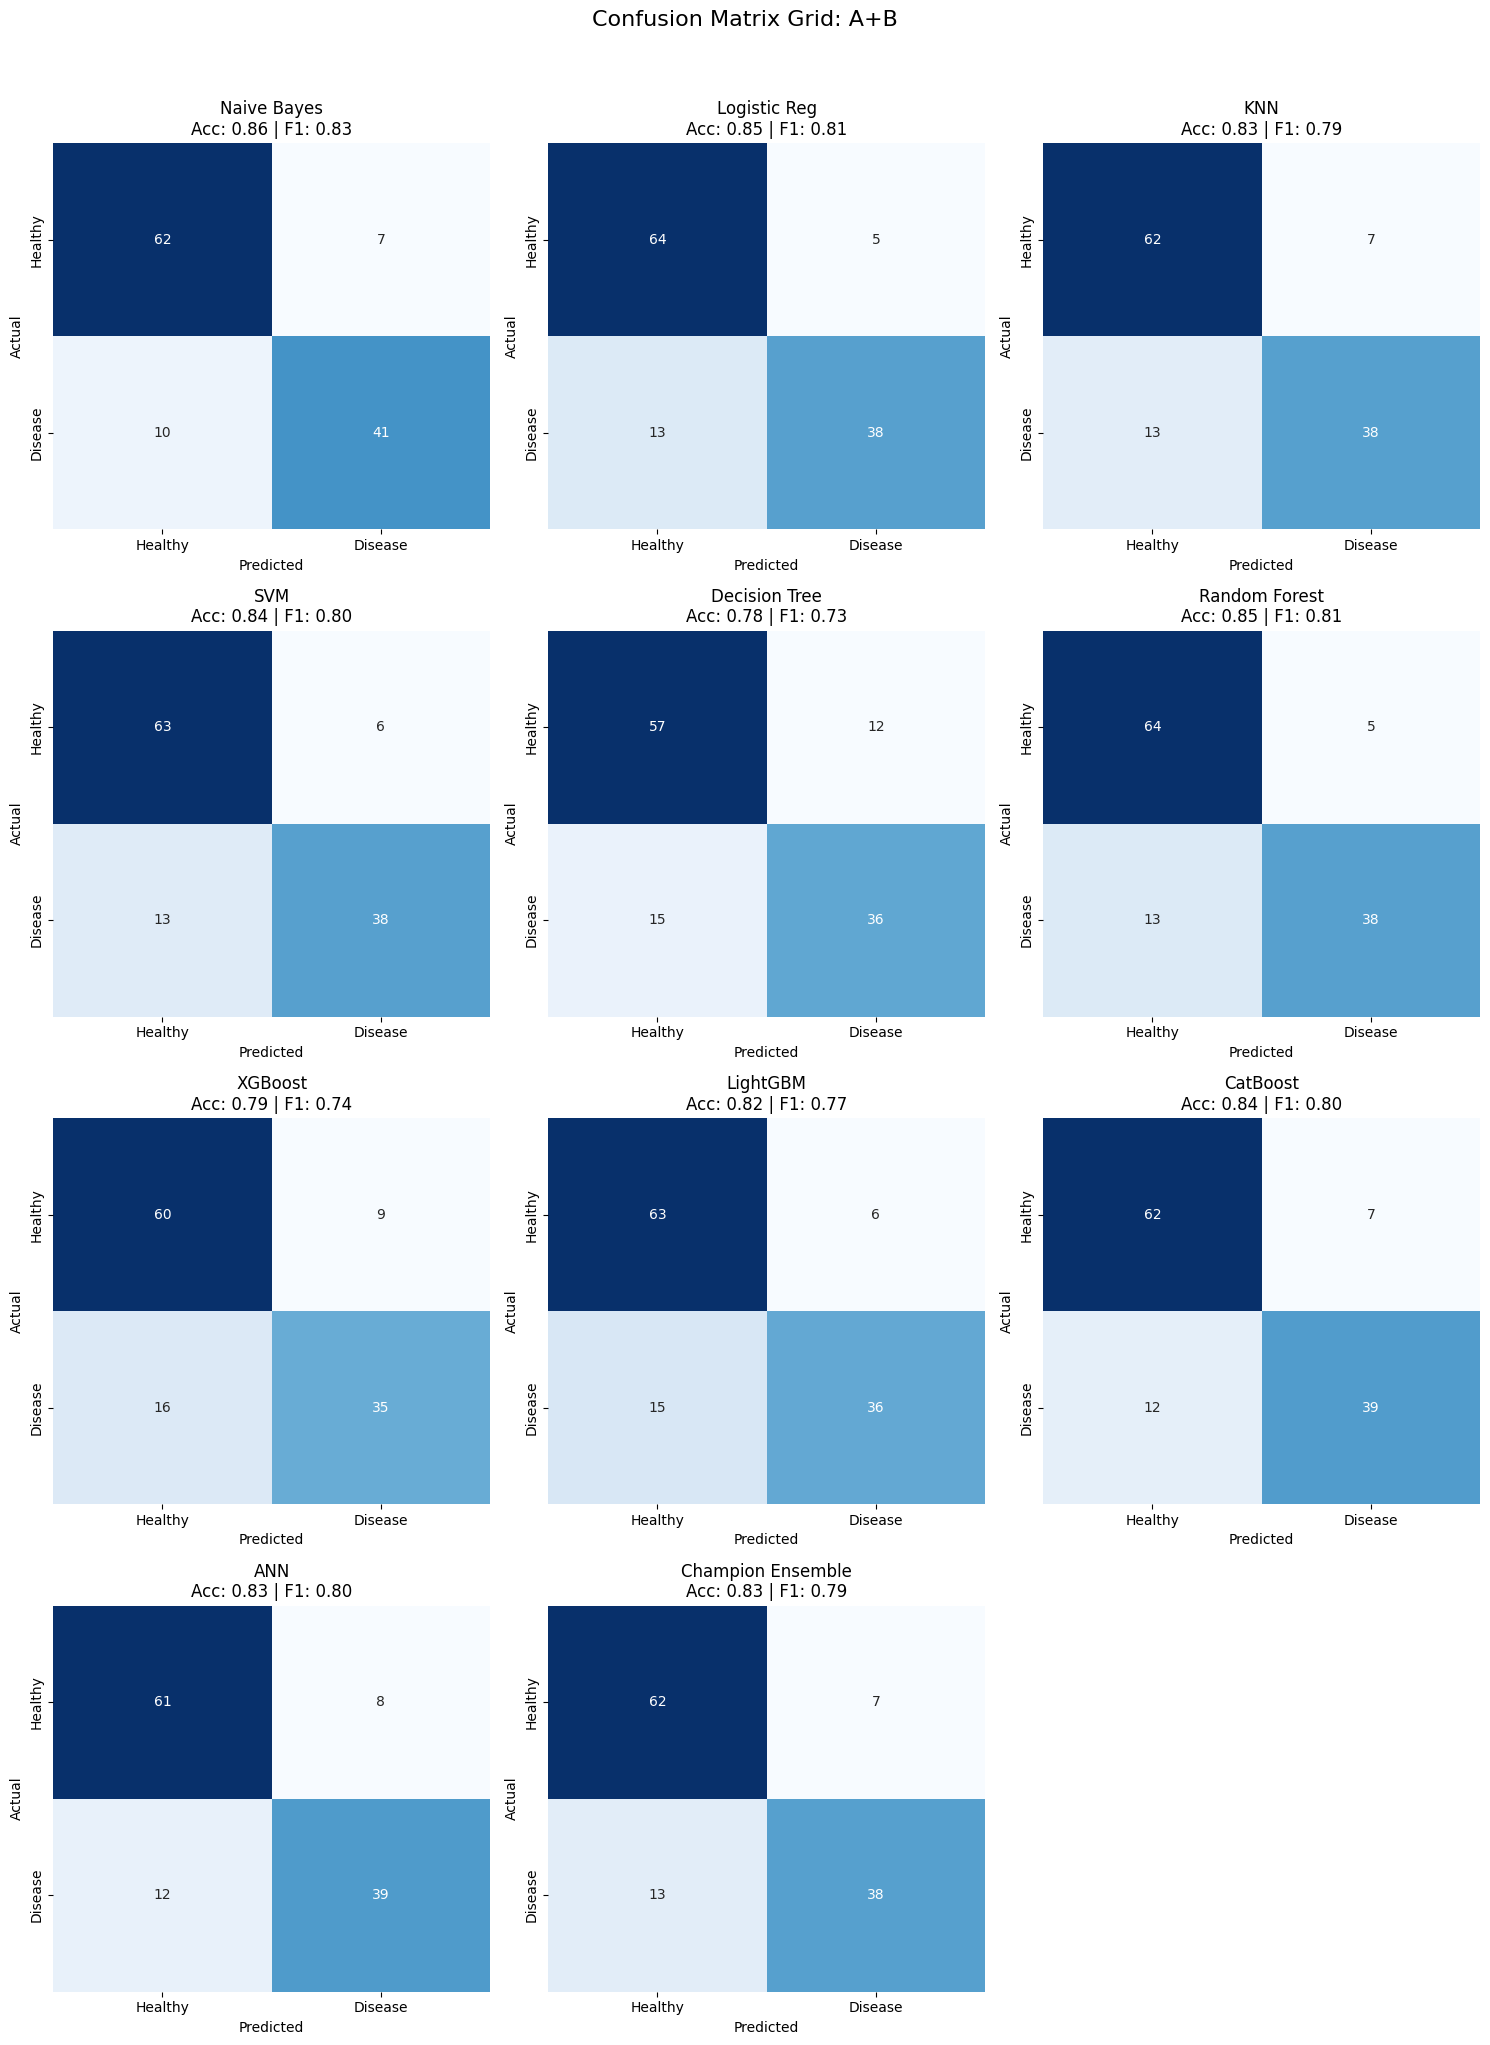


--- Error Analysis (A+B) ---


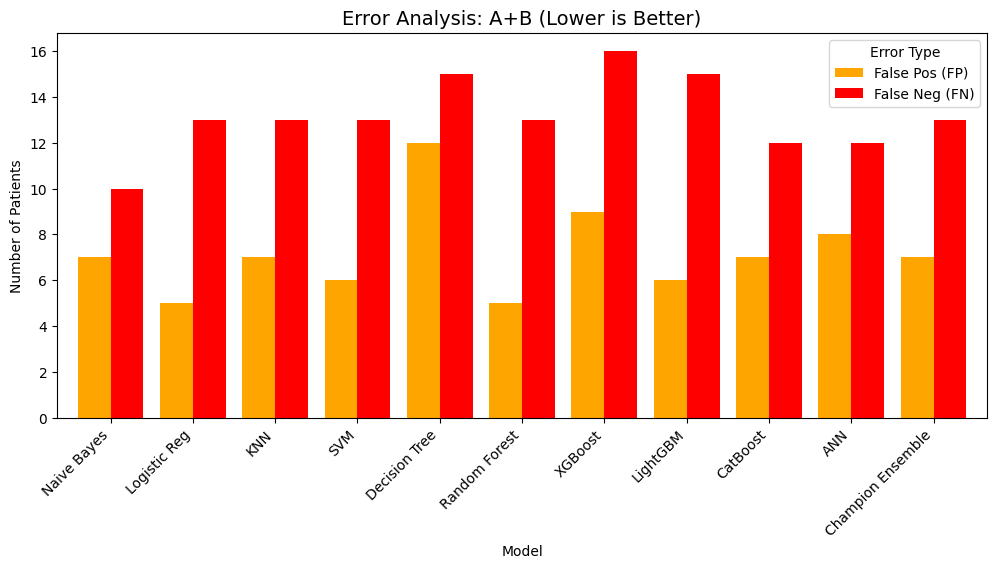




 RUNNING EXPERIMENT: DATASET [A+C]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:46:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: A+C (Samples: 426)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.802326,0.828283,28,4,13,41
Logistic Reg,0.813953,0.840000,28,4,12,42
KNN,0.825581,0.854369,27,5,10,44
SVM,0.802326,0.834951,26,6,11,43
Decision Tree,0.720930,0.744681,27,5,19,35
Random Forest,0.813953,0.836735,29,3,13,41
XGBoost,0.767442,0.800000,26,6,14,40
LightGBM,0.813953,0.846154,26,6,10,44
CatBoost,0.813953,0.843137,27,5,11,43



--- Confusion Matrix Grid (A+C) ---


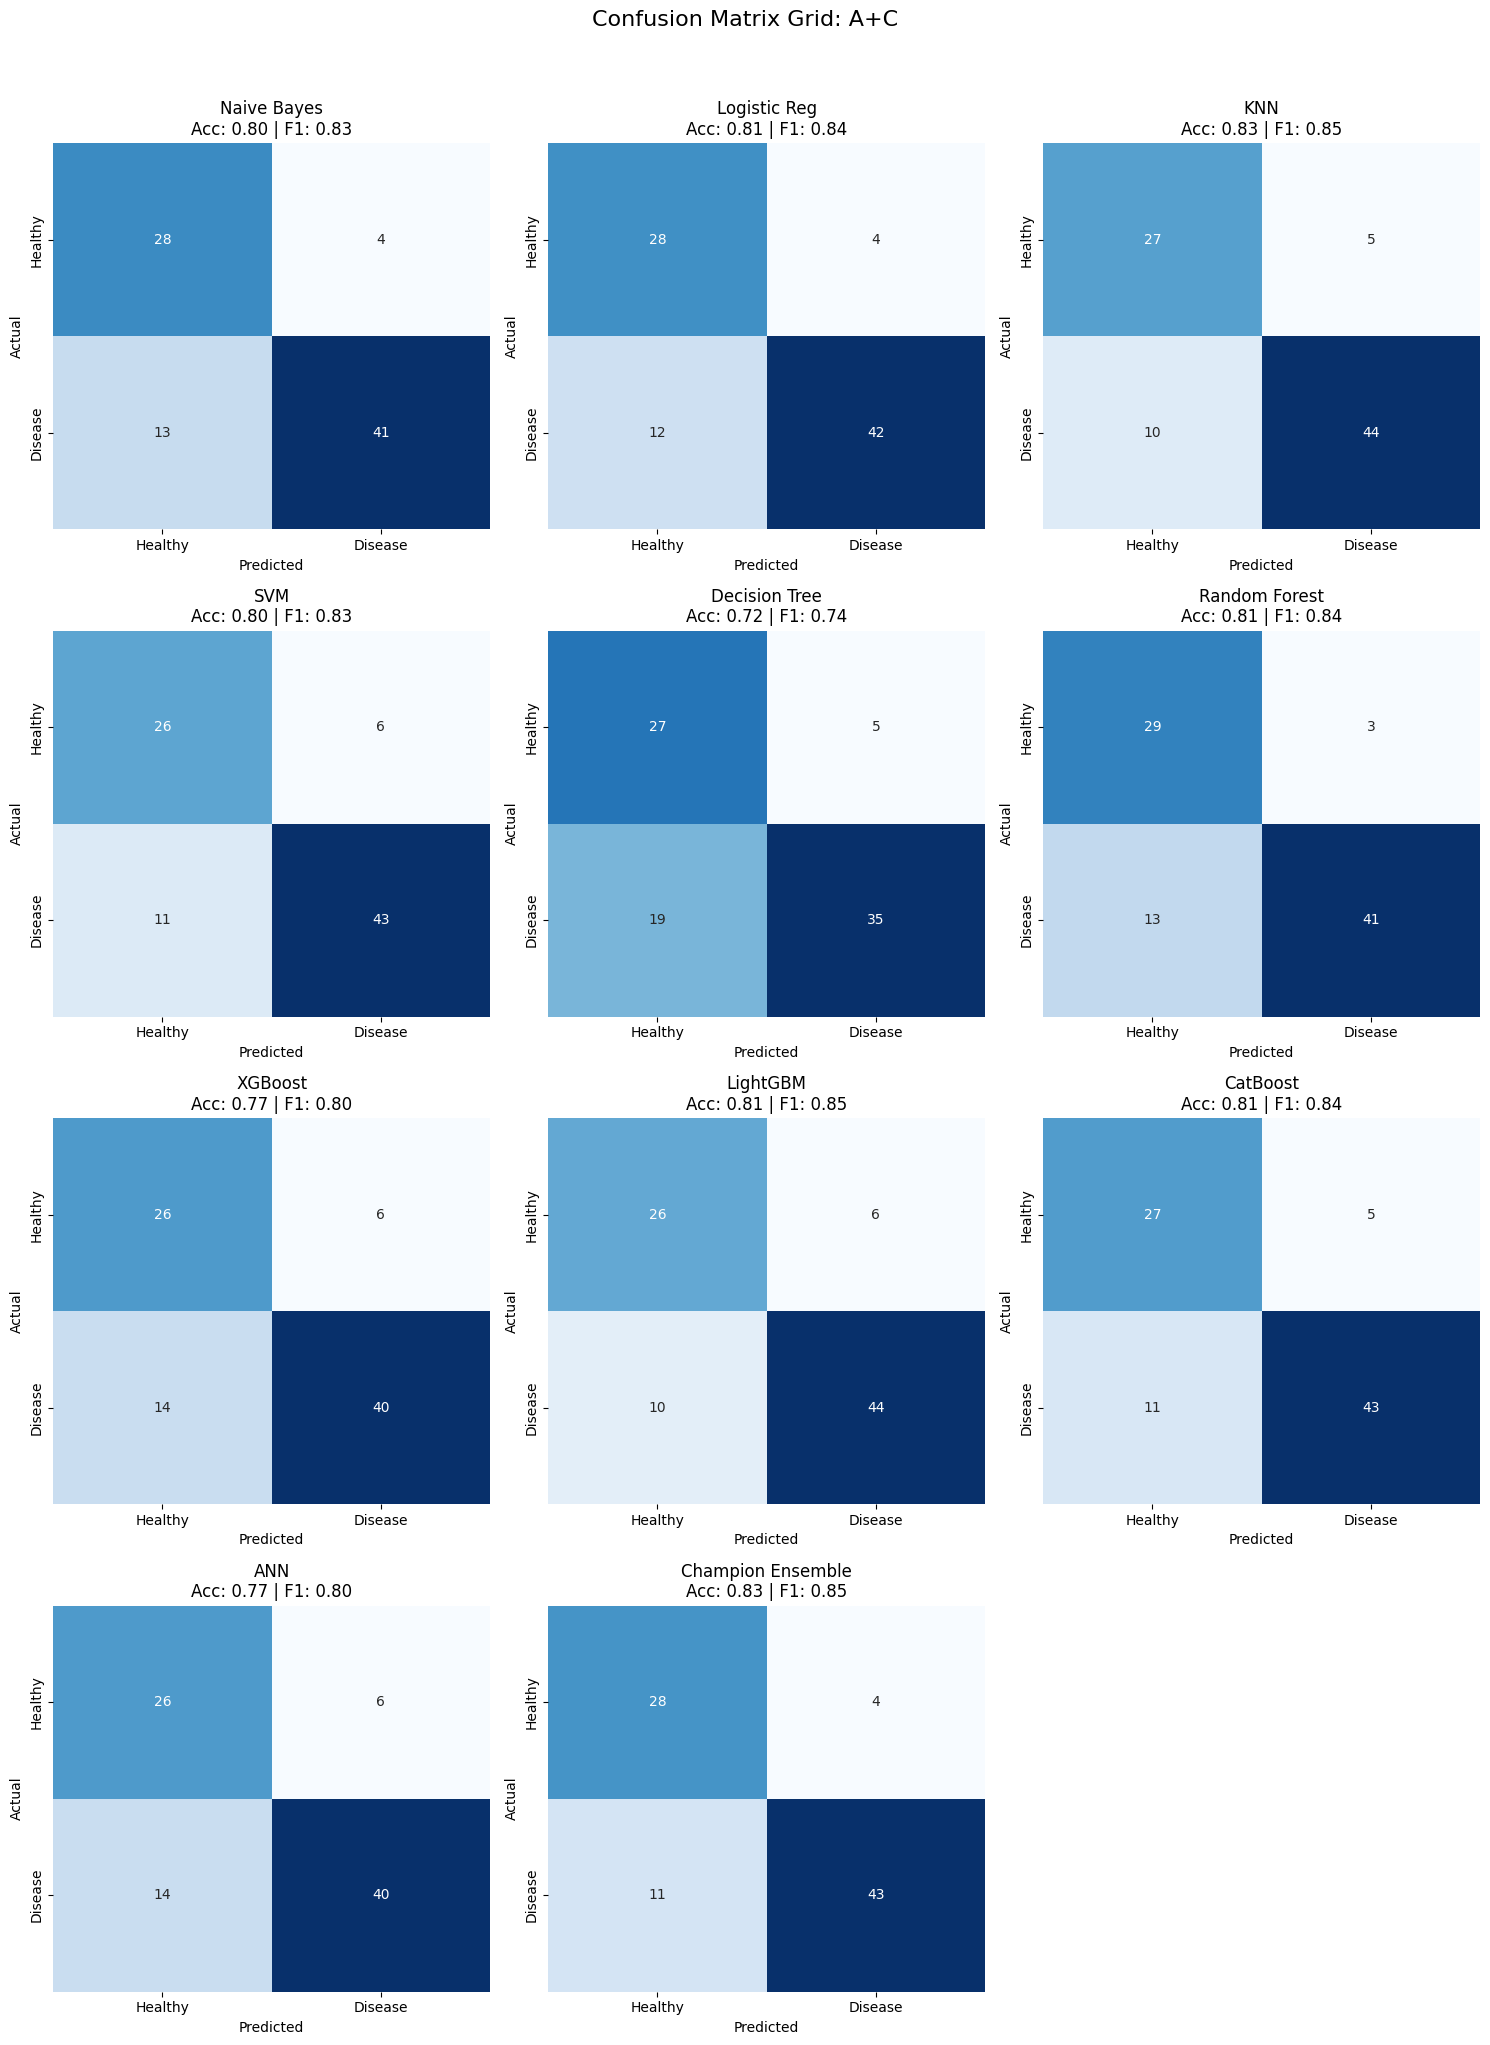


--- Error Analysis (A+C) ---


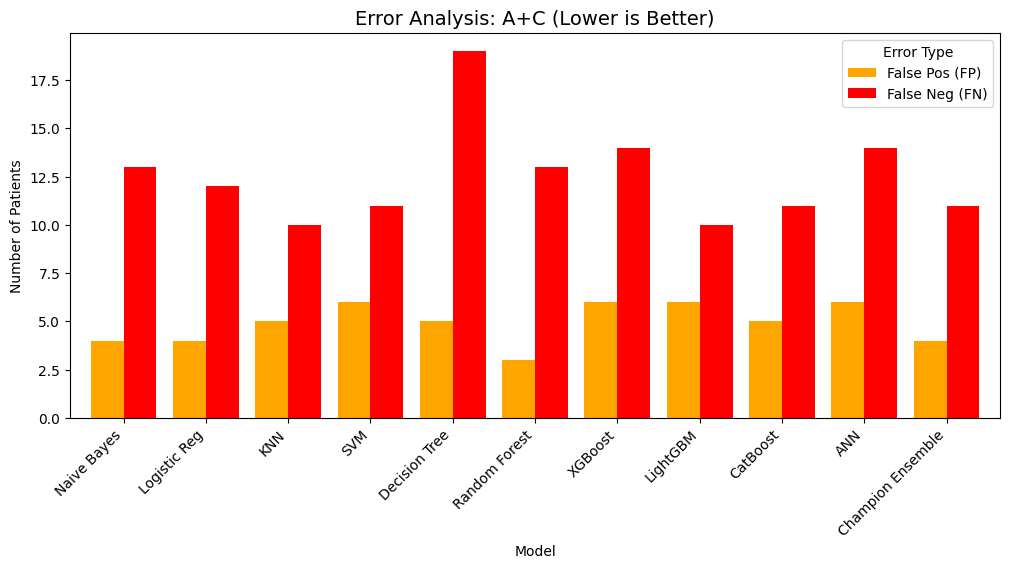




 RUNNING EXPERIMENT: DATASET [A+D]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: A+D (Samples: 503)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.782178,0.784314,39,12,10,40
Logistic Reg,0.742574,0.745098,37,14,12,38
KNN,0.772277,0.780952,37,14,9,41
SVM,0.762376,0.769231,37,14,10,40
Decision Tree,0.673267,0.702703,29,22,11,39
Random Forest,0.742574,0.740000,38,13,13,37
XGBoost,0.742574,0.745098,37,14,12,38
LightGBM,0.742574,0.745098,37,14,12,38
CatBoost,0.762376,0.764706,38,13,11,39



--- Confusion Matrix Grid (A+D) ---


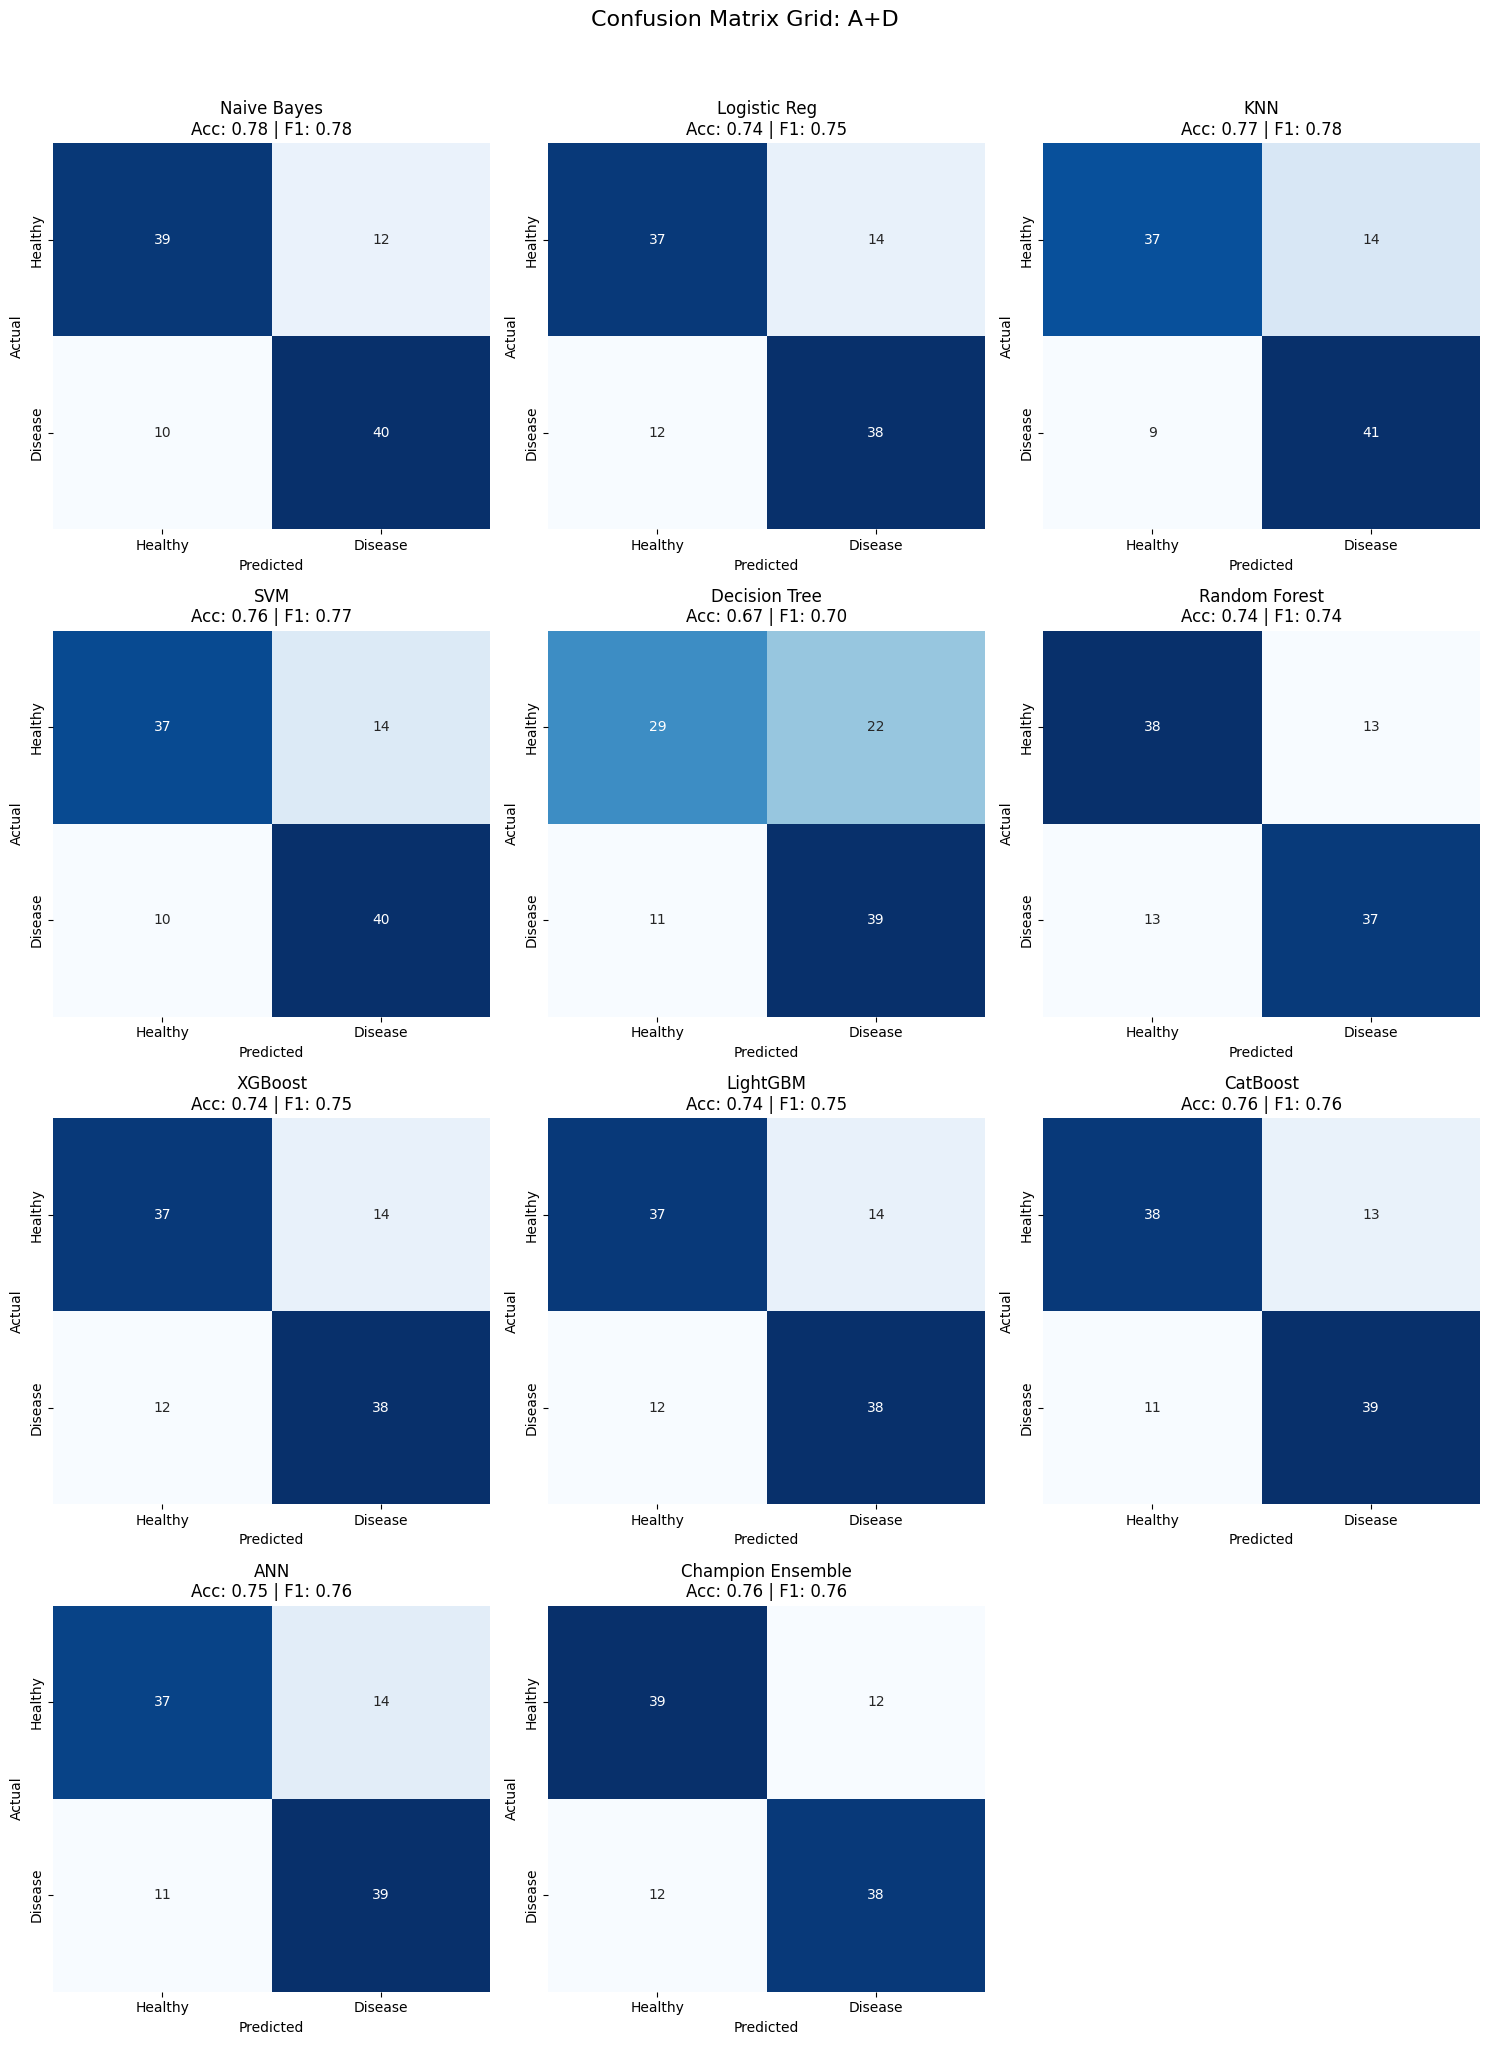


--- Error Analysis (A+D) ---


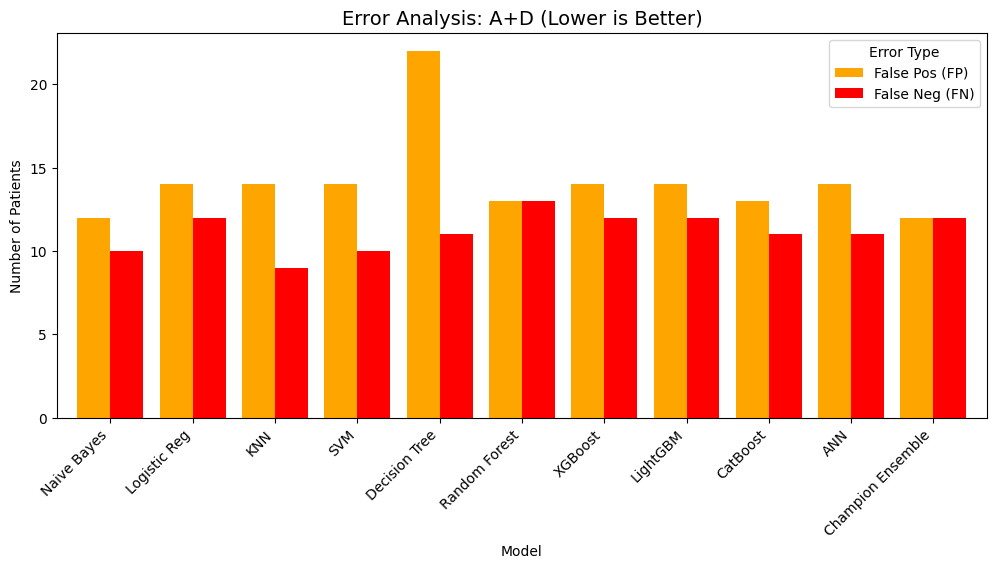




 RUNNING EXPERIMENT: DATASET [B+C]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: B+C (Samples: 417)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.833333,0.833333,35,9,5,35
Logistic Reg,0.785714,0.775000,35,9,9,31
KNN,0.833333,0.825000,37,7,7,33
SVM,0.845238,0.839506,37,7,6,34
Decision Tree,0.797619,0.779221,37,7,10,30
Random Forest,0.821429,0.819277,35,9,6,34
XGBoost,0.761905,0.767442,31,13,7,33
LightGBM,0.809524,0.818182,32,12,4,36
CatBoost,0.821429,0.819277,35,9,6,34



--- Confusion Matrix Grid (B+C) ---


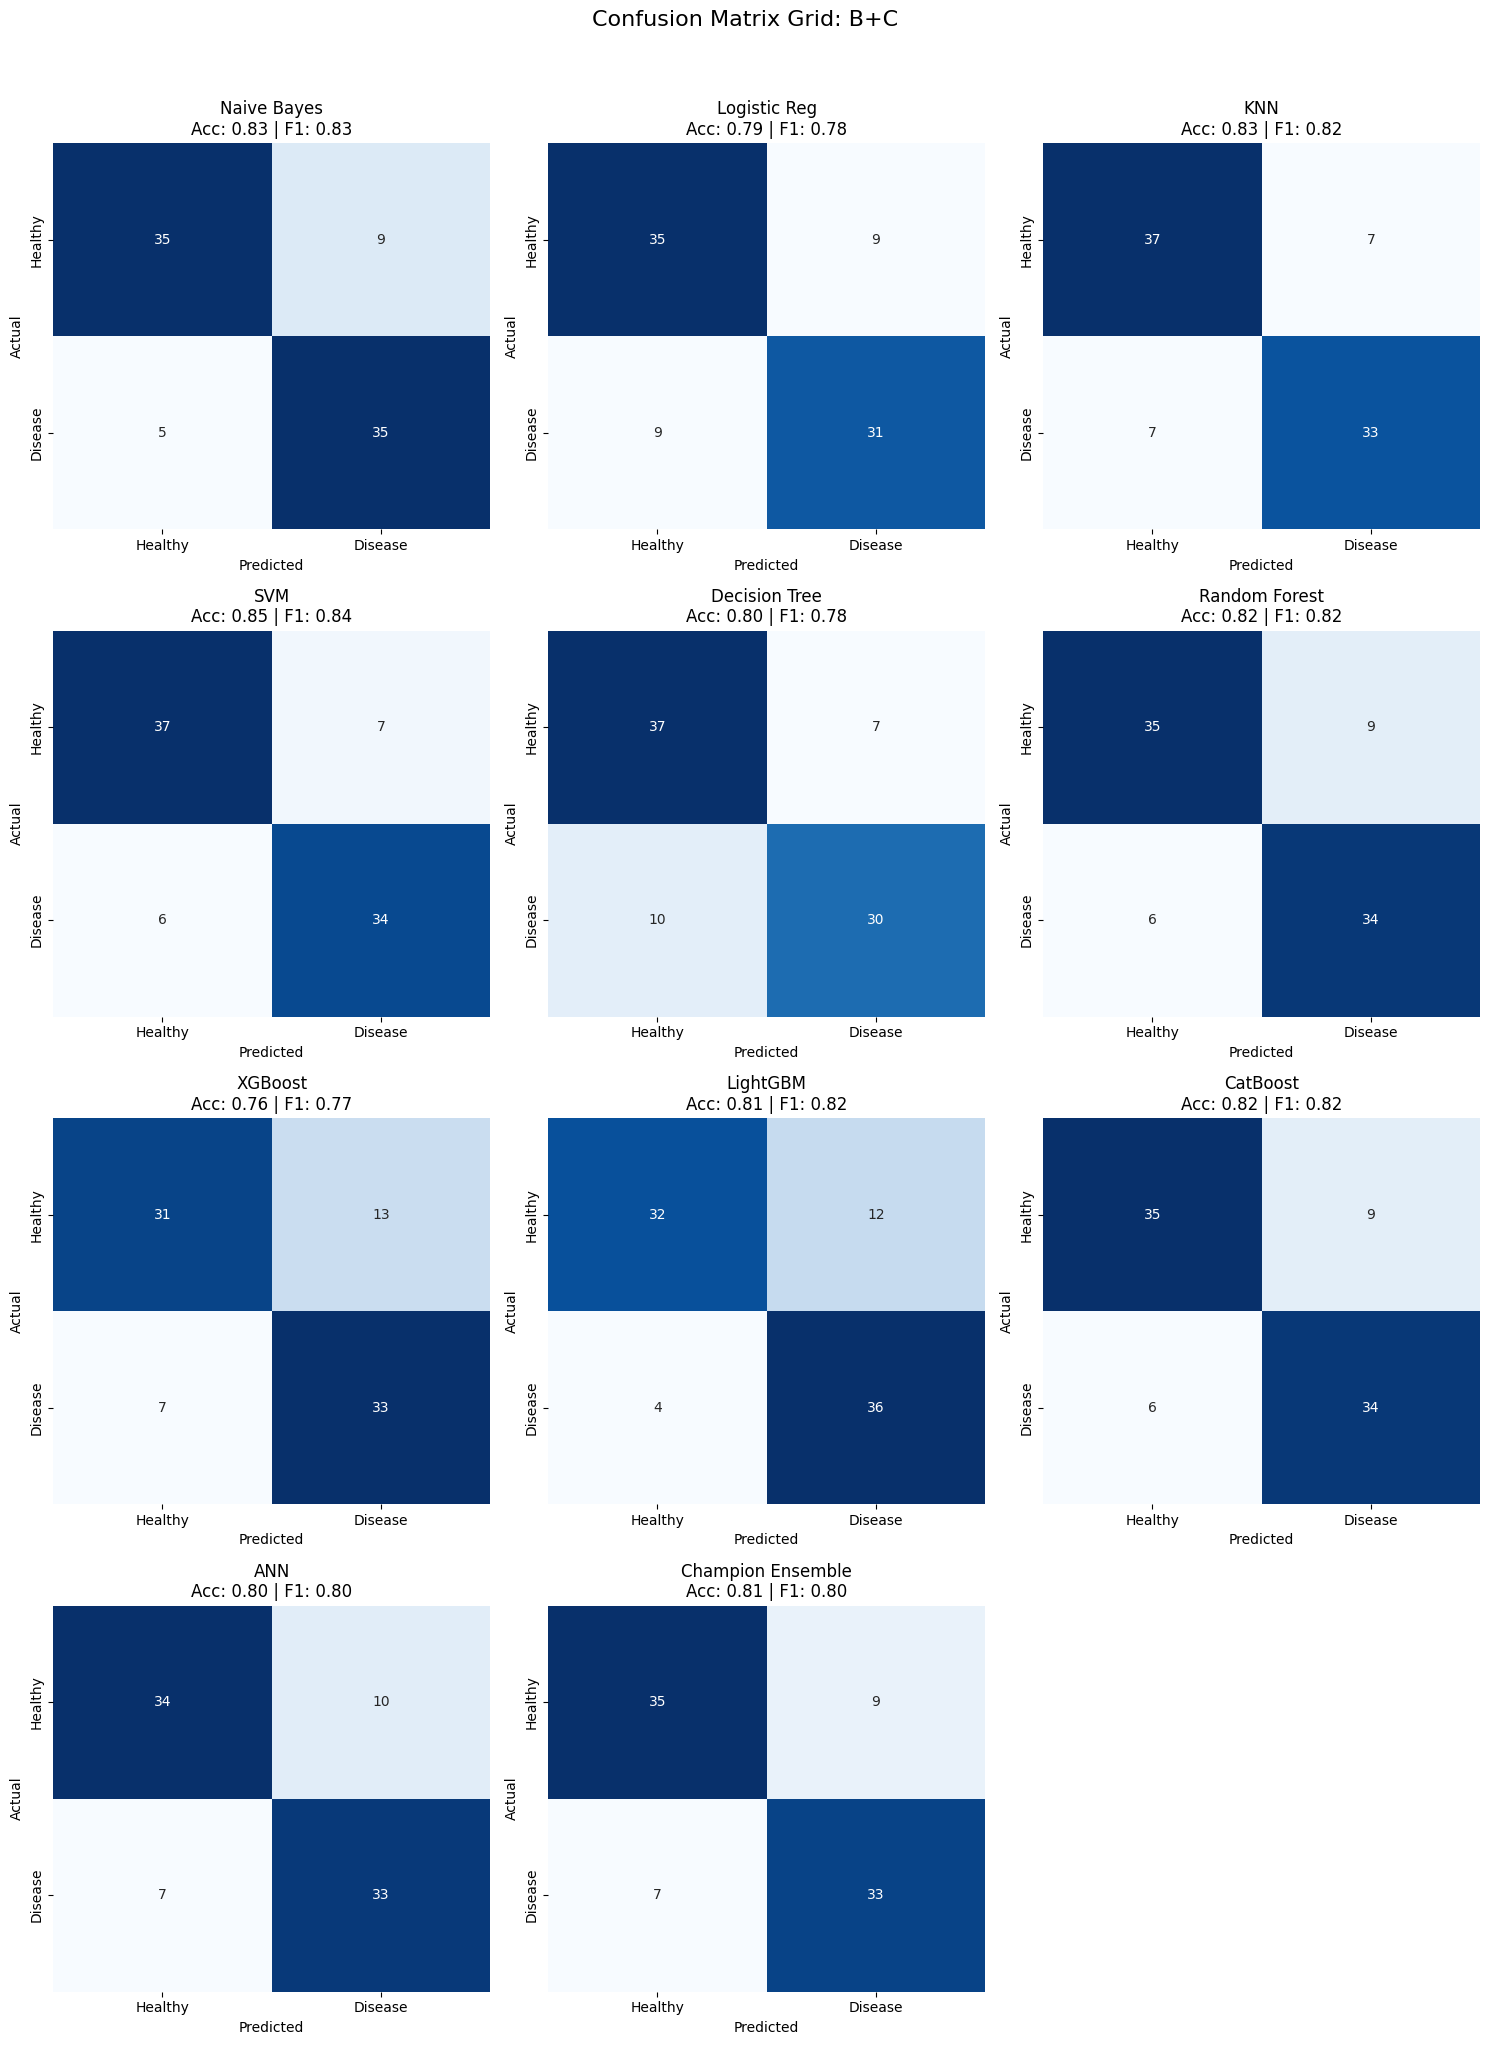


--- Error Analysis (B+C) ---


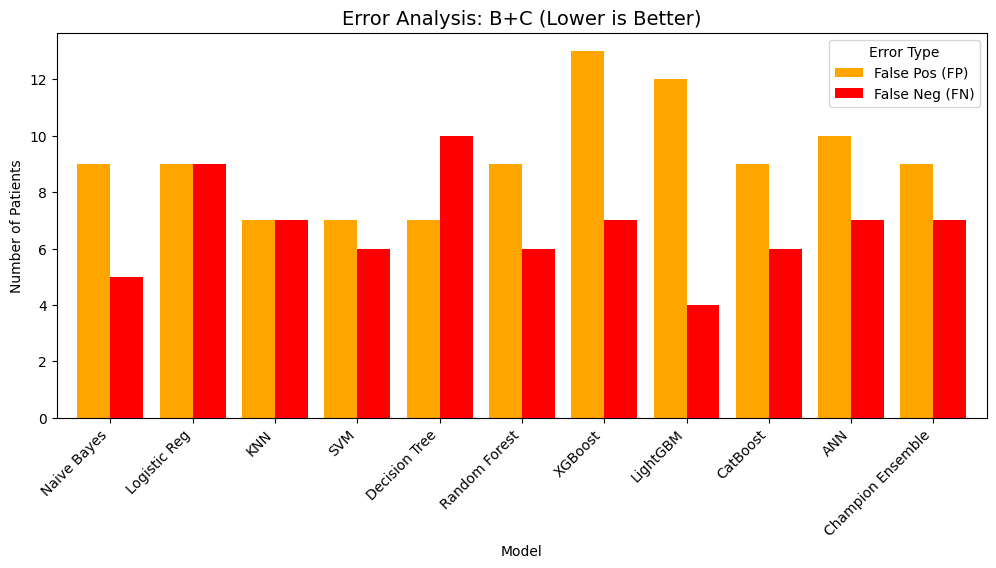




 RUNNING EXPERIMENT: DATASET [B+D]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: B+D (Samples: 494)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.848485,0.851485,41,10,5,43
Logistic Reg,0.808081,0.811881,39,12,7,41
KNN,0.818182,0.823529,39,12,6,42
SVM,0.838384,0.843137,40,11,5,43
Decision Tree,0.737374,0.734694,37,14,12,36
Random Forest,0.777778,0.784314,37,14,8,40
XGBoost,0.747475,0.766355,33,18,7,41
LightGBM,0.757576,0.769231,35,16,8,40
CatBoost,0.777778,0.788462,36,15,7,41



--- Confusion Matrix Grid (B+D) ---


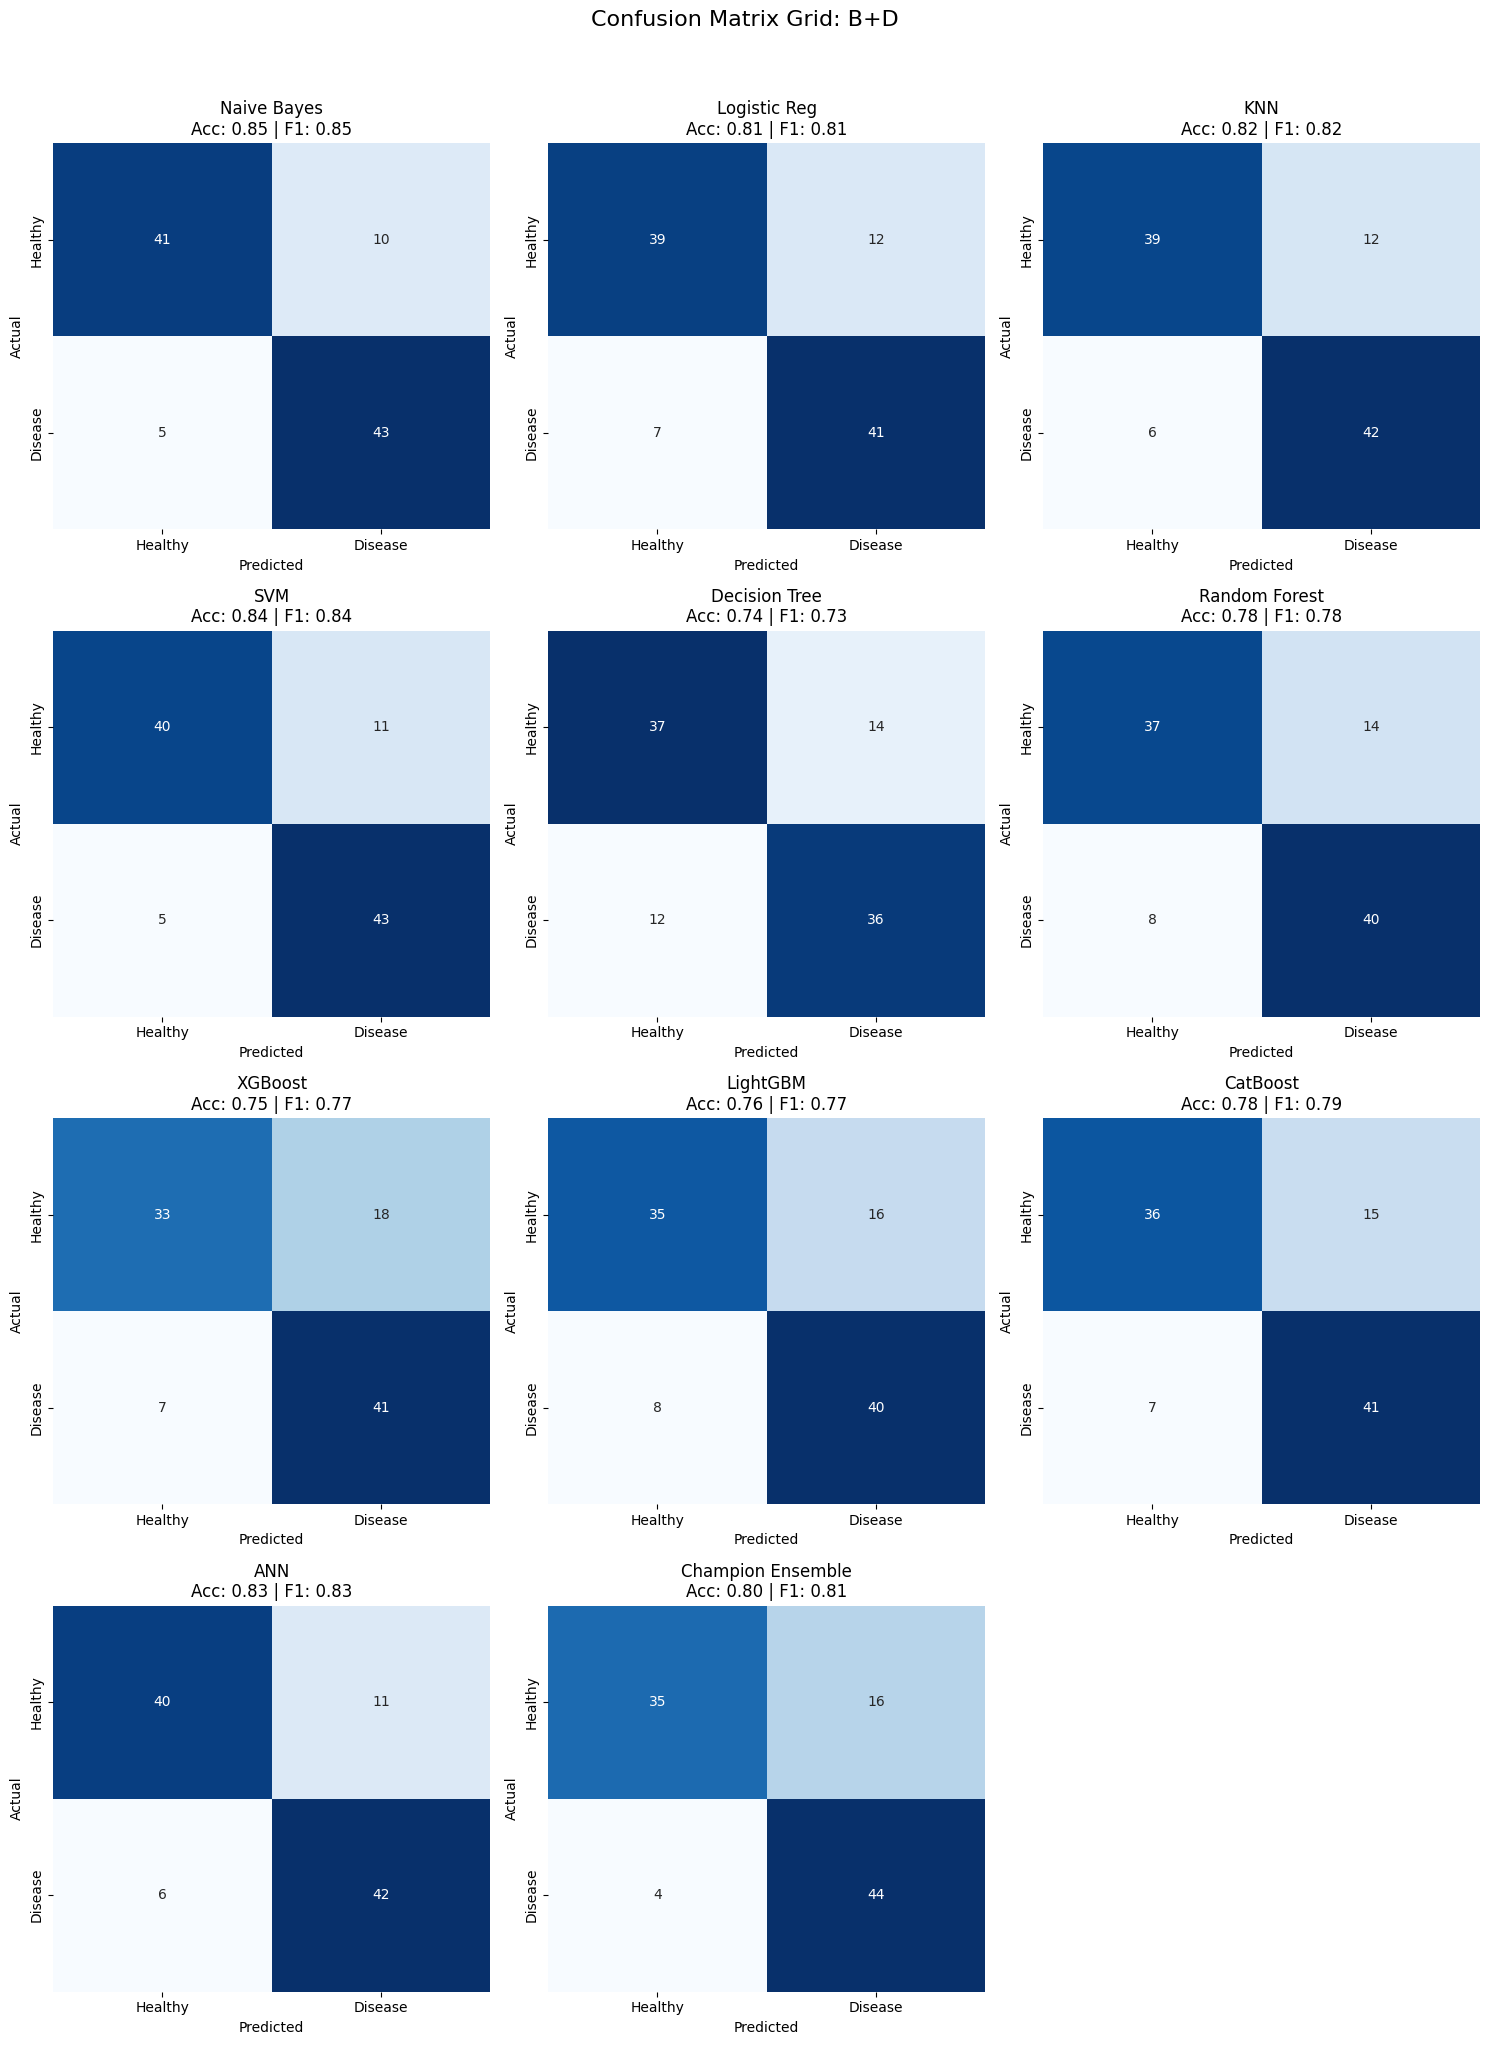


--- Error Analysis (B+D) ---


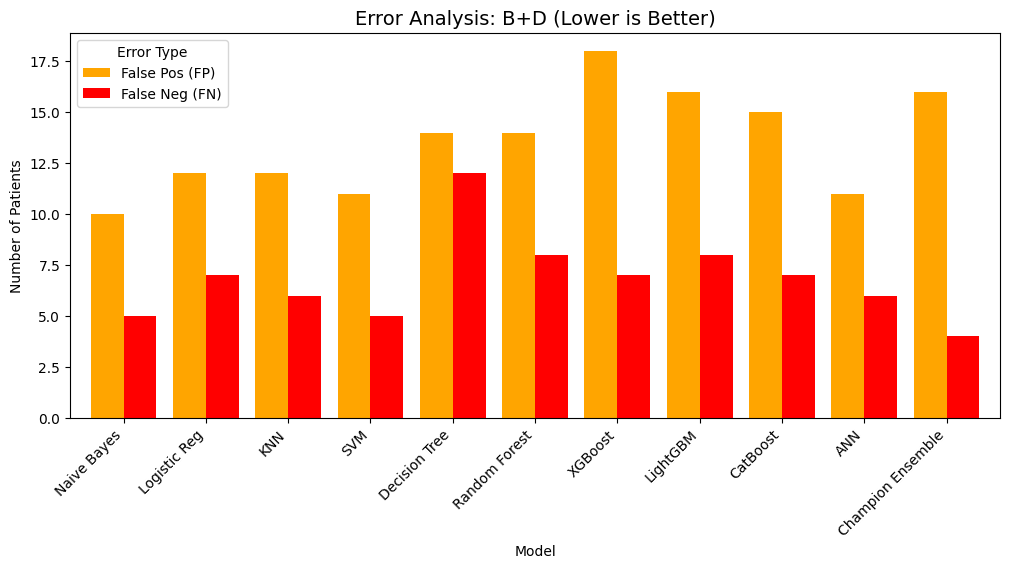




 RUNNING EXPERIMENT: DATASET [C+D]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: C+D (Samples: 323)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.800000,0.888889,0,8,5,52
Logistic Reg,0.830769,0.905983,1,7,4,53
KNN,0.861538,0.924370,1,7,2,55
SVM,0.861538,0.925620,0,8,1,56
Decision Tree,0.830769,0.902655,3,5,6,51
Random Forest,0.846154,0.916667,0,8,2,55
XGBoost,0.815385,0.896552,1,7,5,52
LightGBM,0.830769,0.905983,1,7,4,53
CatBoost,0.861538,0.925620,0,8,1,56



--- Confusion Matrix Grid (C+D) ---


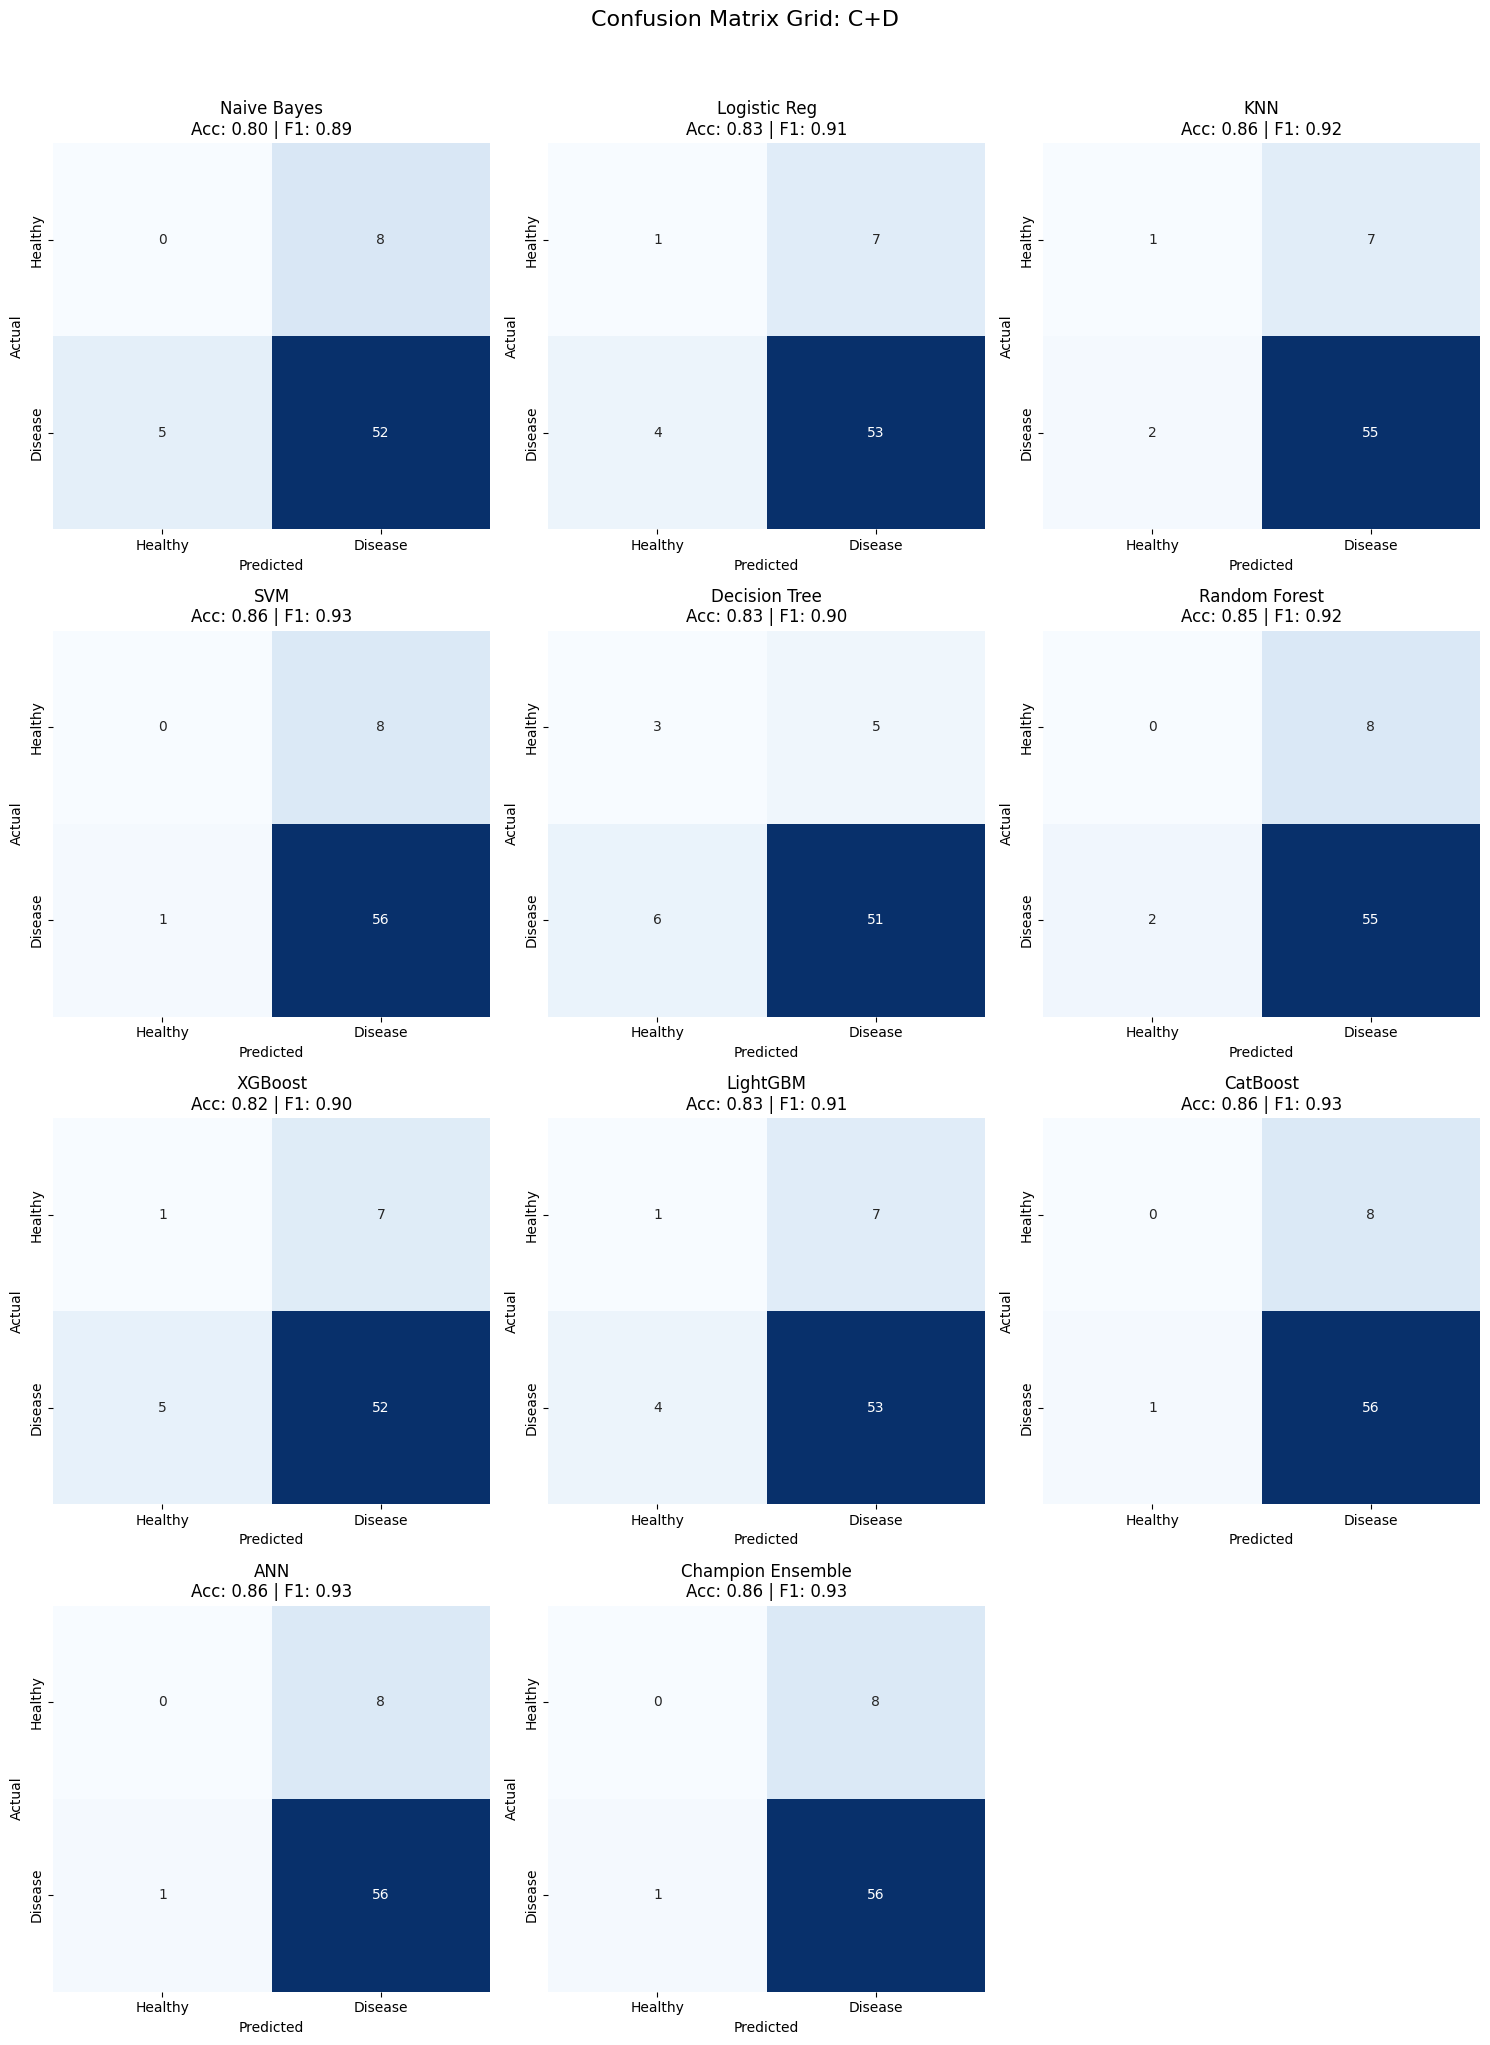


--- Error Analysis (C+D) ---


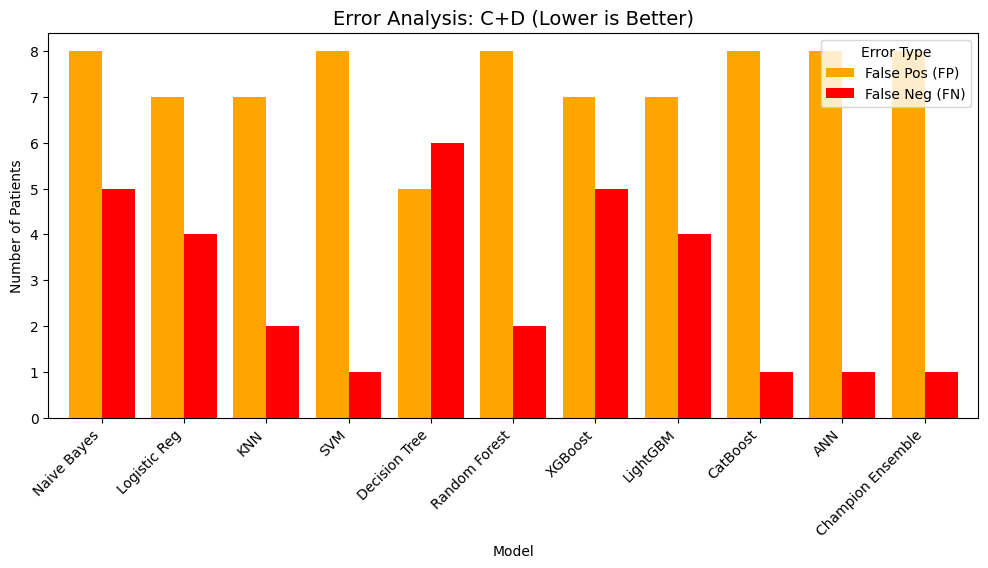




 RUNNING EXPERIMENT: DATASET [A+B+C]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:47:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: A+B+C (Samples: 720)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.861111,0.855072,65,6,14,59
Logistic Reg,0.833333,0.826087,63,8,16,57
KNN,0.847222,0.842857,63,8,14,59
SVM,0.854167,0.848921,64,7,14,59
Decision Tree,0.798611,0.788321,61,10,19,54
Random Forest,0.840278,0.832117,64,7,16,57
XGBoost,0.868056,0.861314,66,5,14,59
LightGBM,0.854167,0.848921,64,7,14,59
CatBoost,0.868056,0.865248,64,7,12,61



--- Confusion Matrix Grid (A+B+C) ---


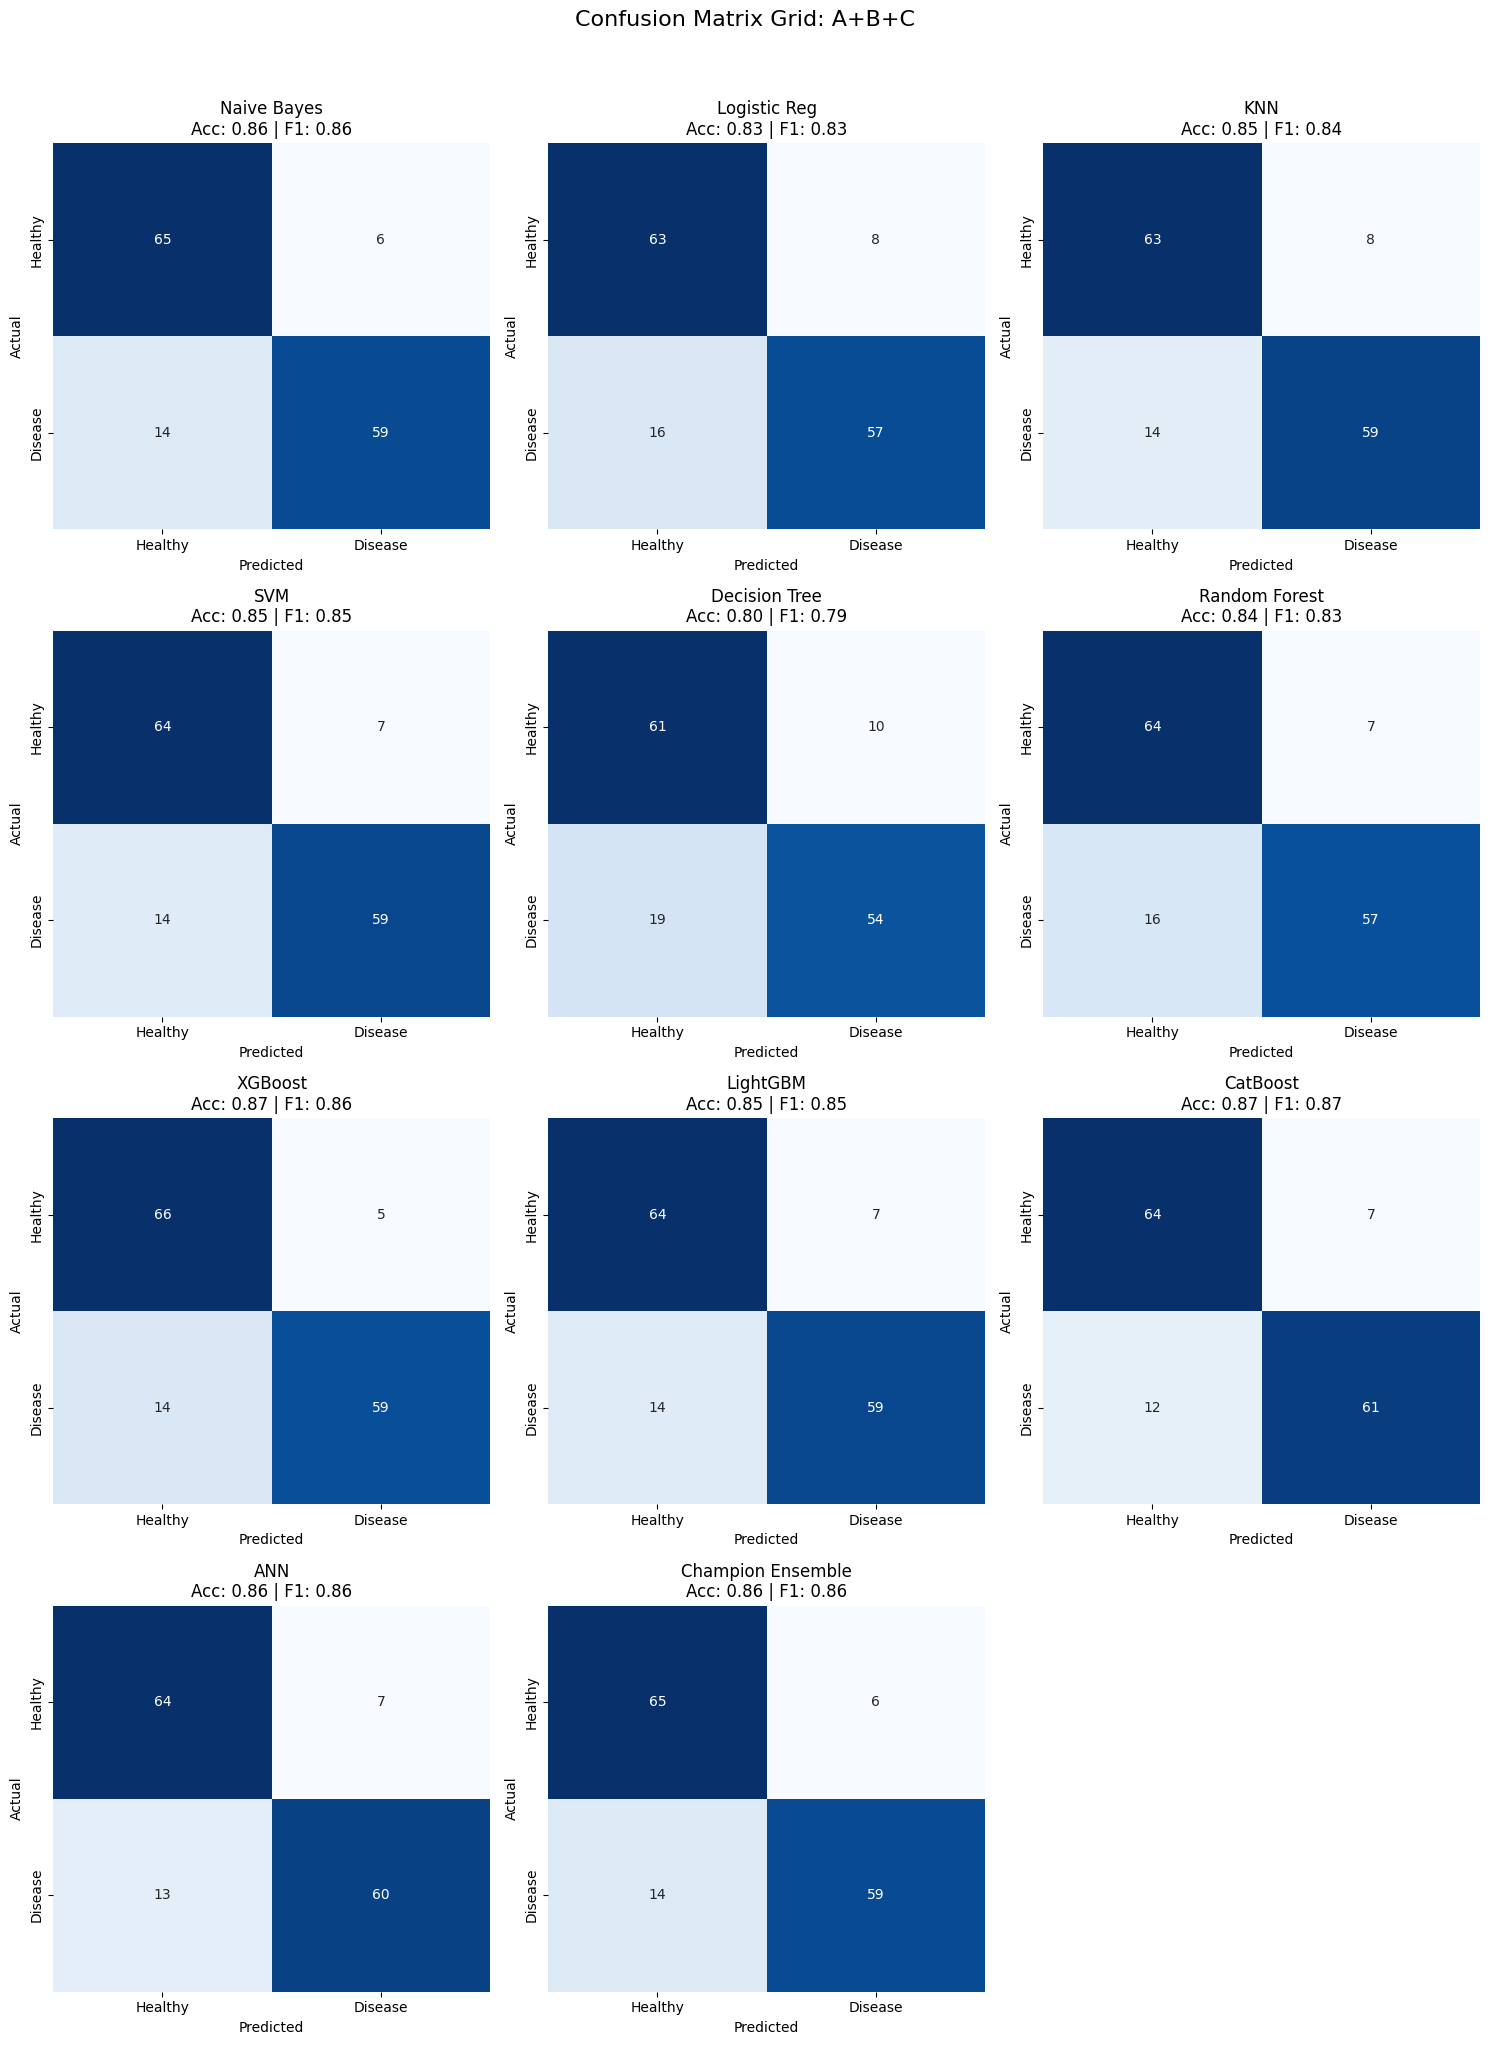


--- Error Analysis (A+B+C) ---


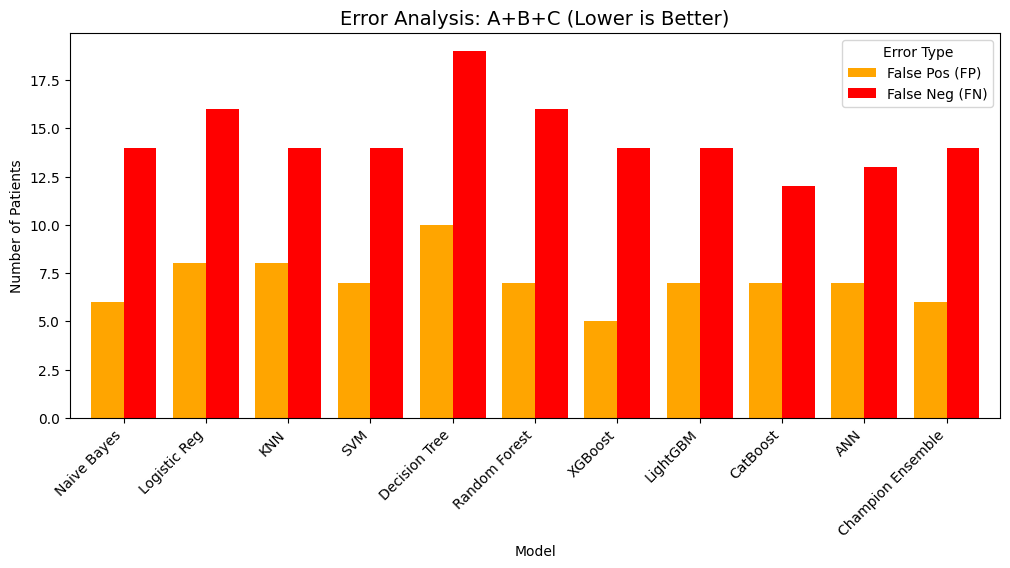




 RUNNING EXPERIMENT: DATASET [A+B+D]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:48:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: A+B+D (Samples: 797)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.831250,0.843931,60,16,11,73
Logistic Reg,0.831250,0.843931,60,16,11,73
KNN,0.825000,0.840909,58,18,10,74
SVM,0.818750,0.832370,59,17,12,72
Decision Tree,0.731250,0.732919,58,18,25,59
Random Forest,0.793750,0.804734,59,17,16,68
XGBoost,0.775000,0.788235,57,19,17,67
LightGBM,0.762500,0.773810,57,19,19,65
CatBoost,0.818750,0.830409,60,16,13,71



--- Confusion Matrix Grid (A+B+D) ---


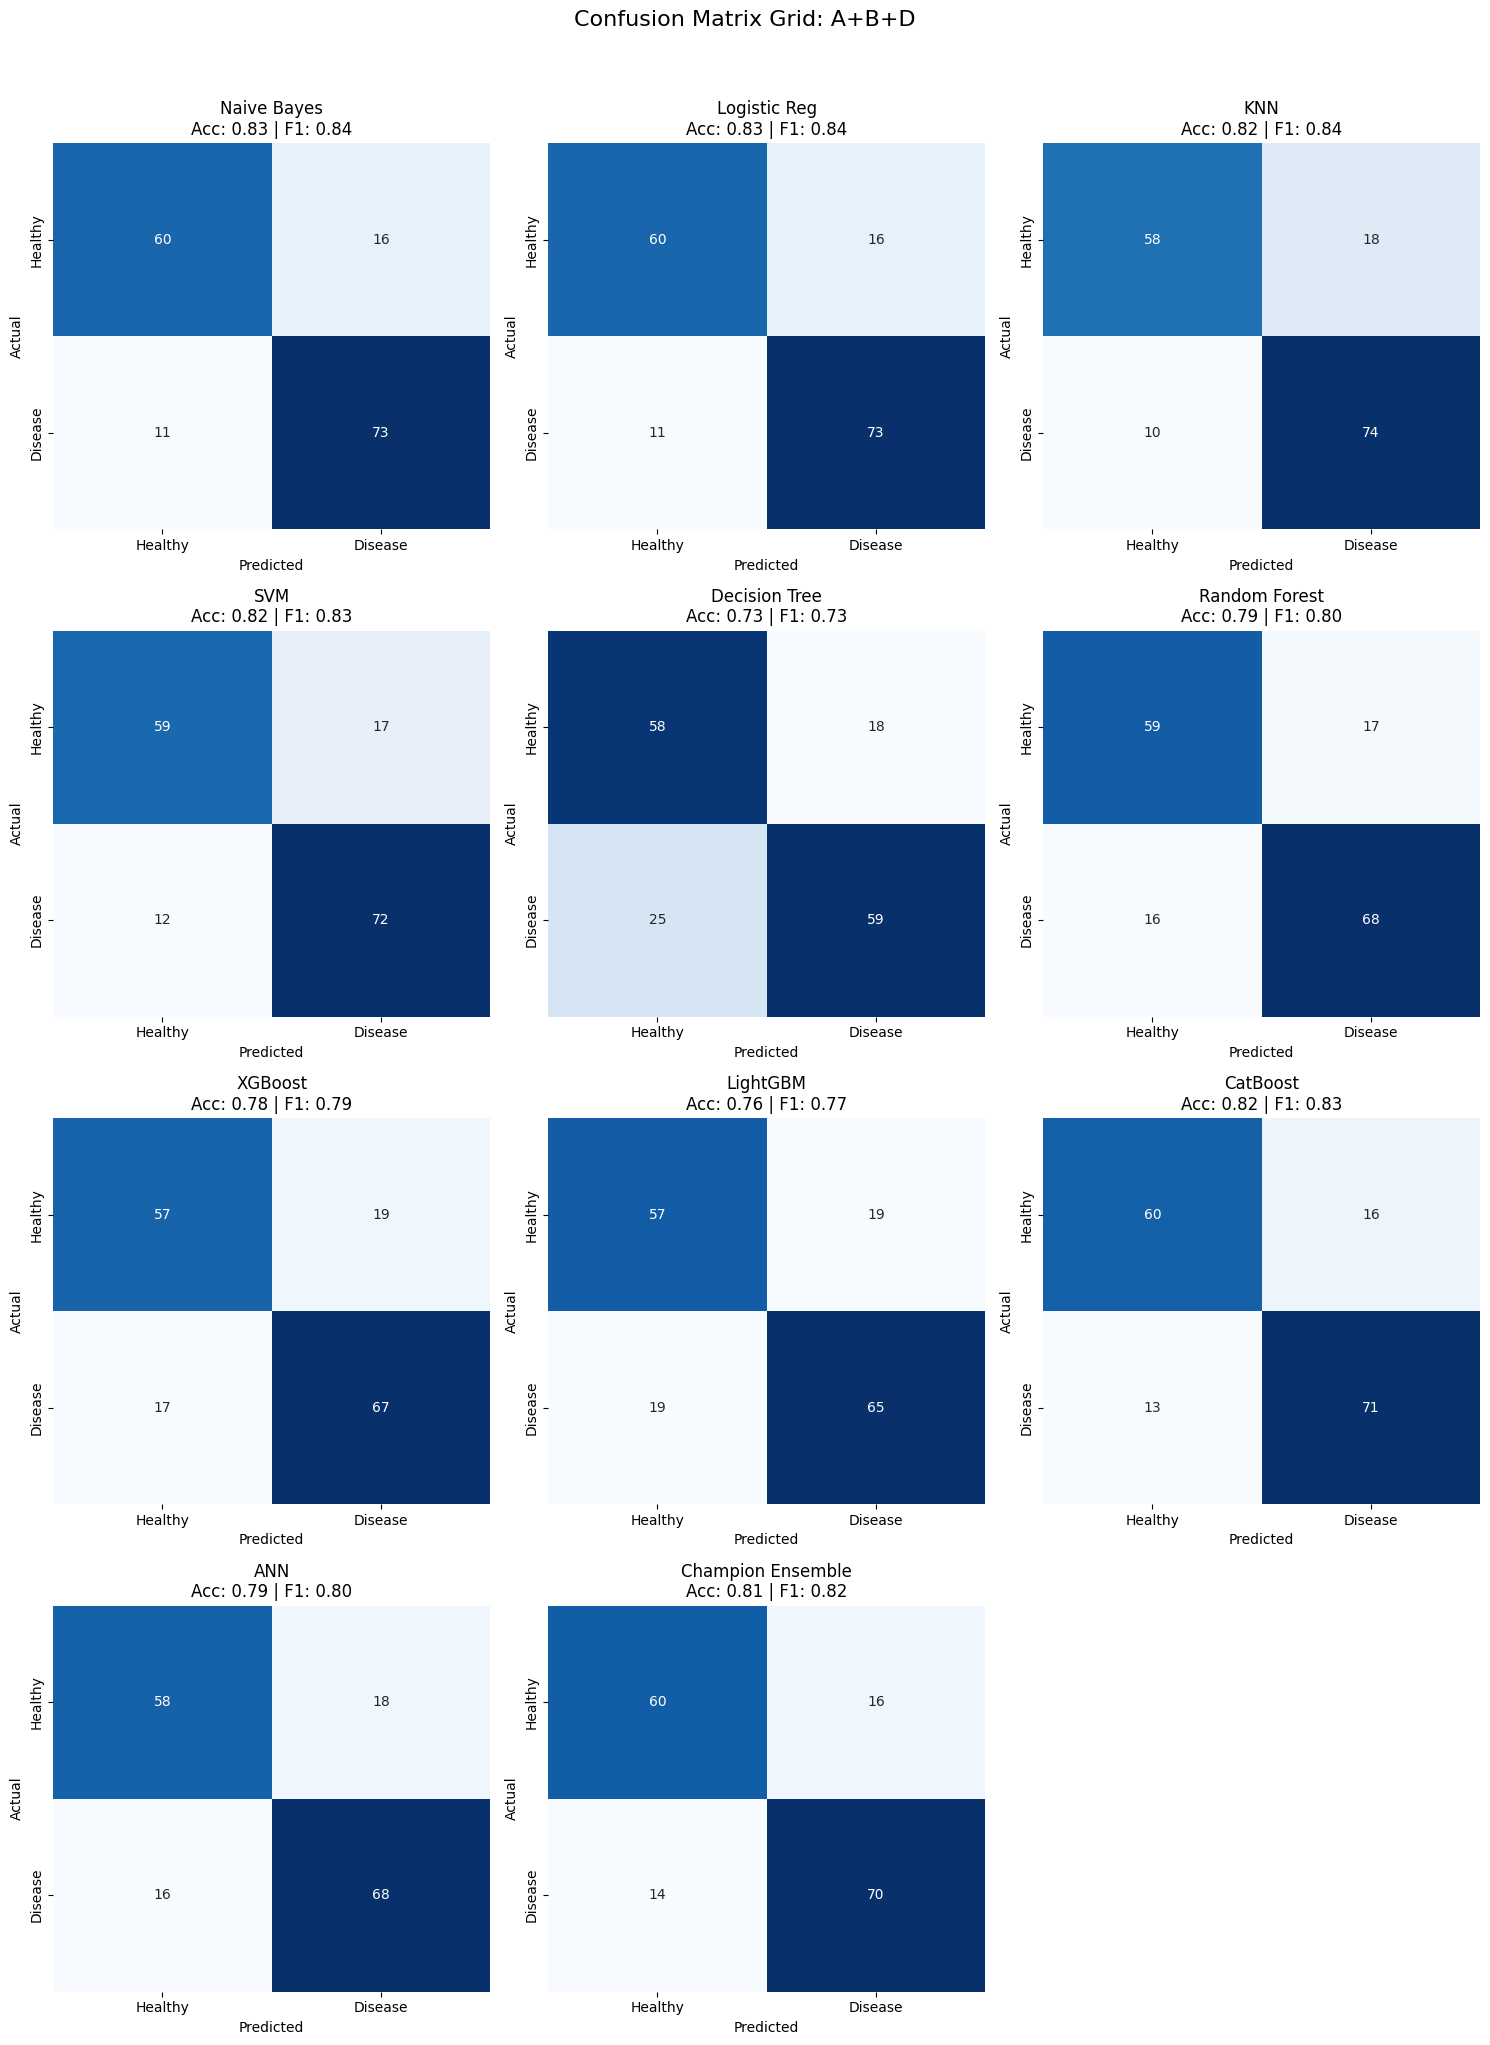


--- Error Analysis (A+B+D) ---


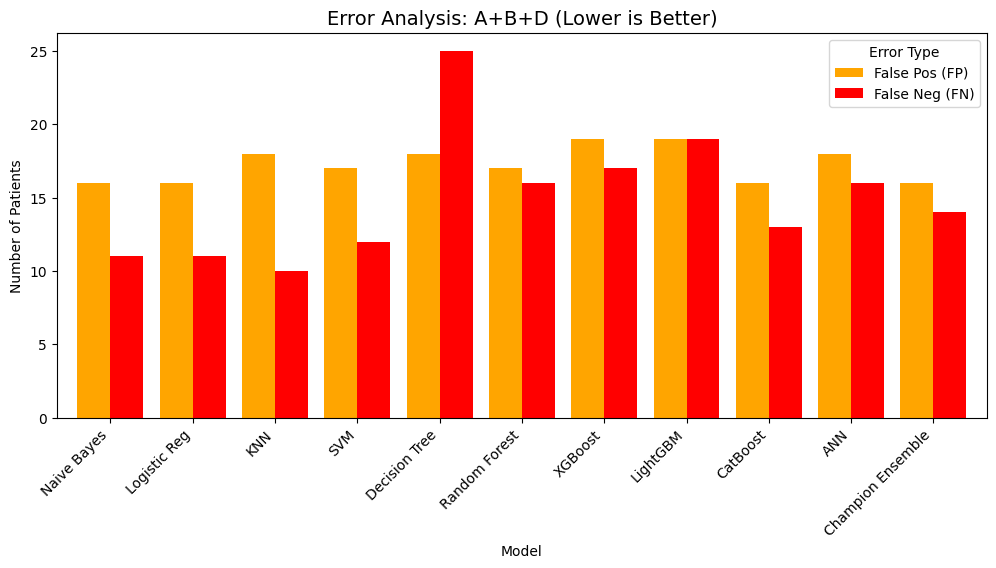




 RUNNING EXPERIMENT: DATASET [A+C+D]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:48:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: A+C+D (Samples: 626)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.785714,0.832298,32,9,18,67
Logistic Reg,0.809524,0.855422,31,10,14,71
KNN,0.777778,0.829268,30,11,17,68
SVM,0.809524,0.860465,28,13,11,74
Decision Tree,0.746032,0.809524,26,15,17,68
Random Forest,0.801587,0.853801,28,13,12,73
XGBoost,0.785714,0.840237,28,13,14,71
LightGBM,0.793651,0.845238,29,12,14,71
CatBoost,0.809524,0.858824,29,12,12,73



--- Confusion Matrix Grid (A+C+D) ---


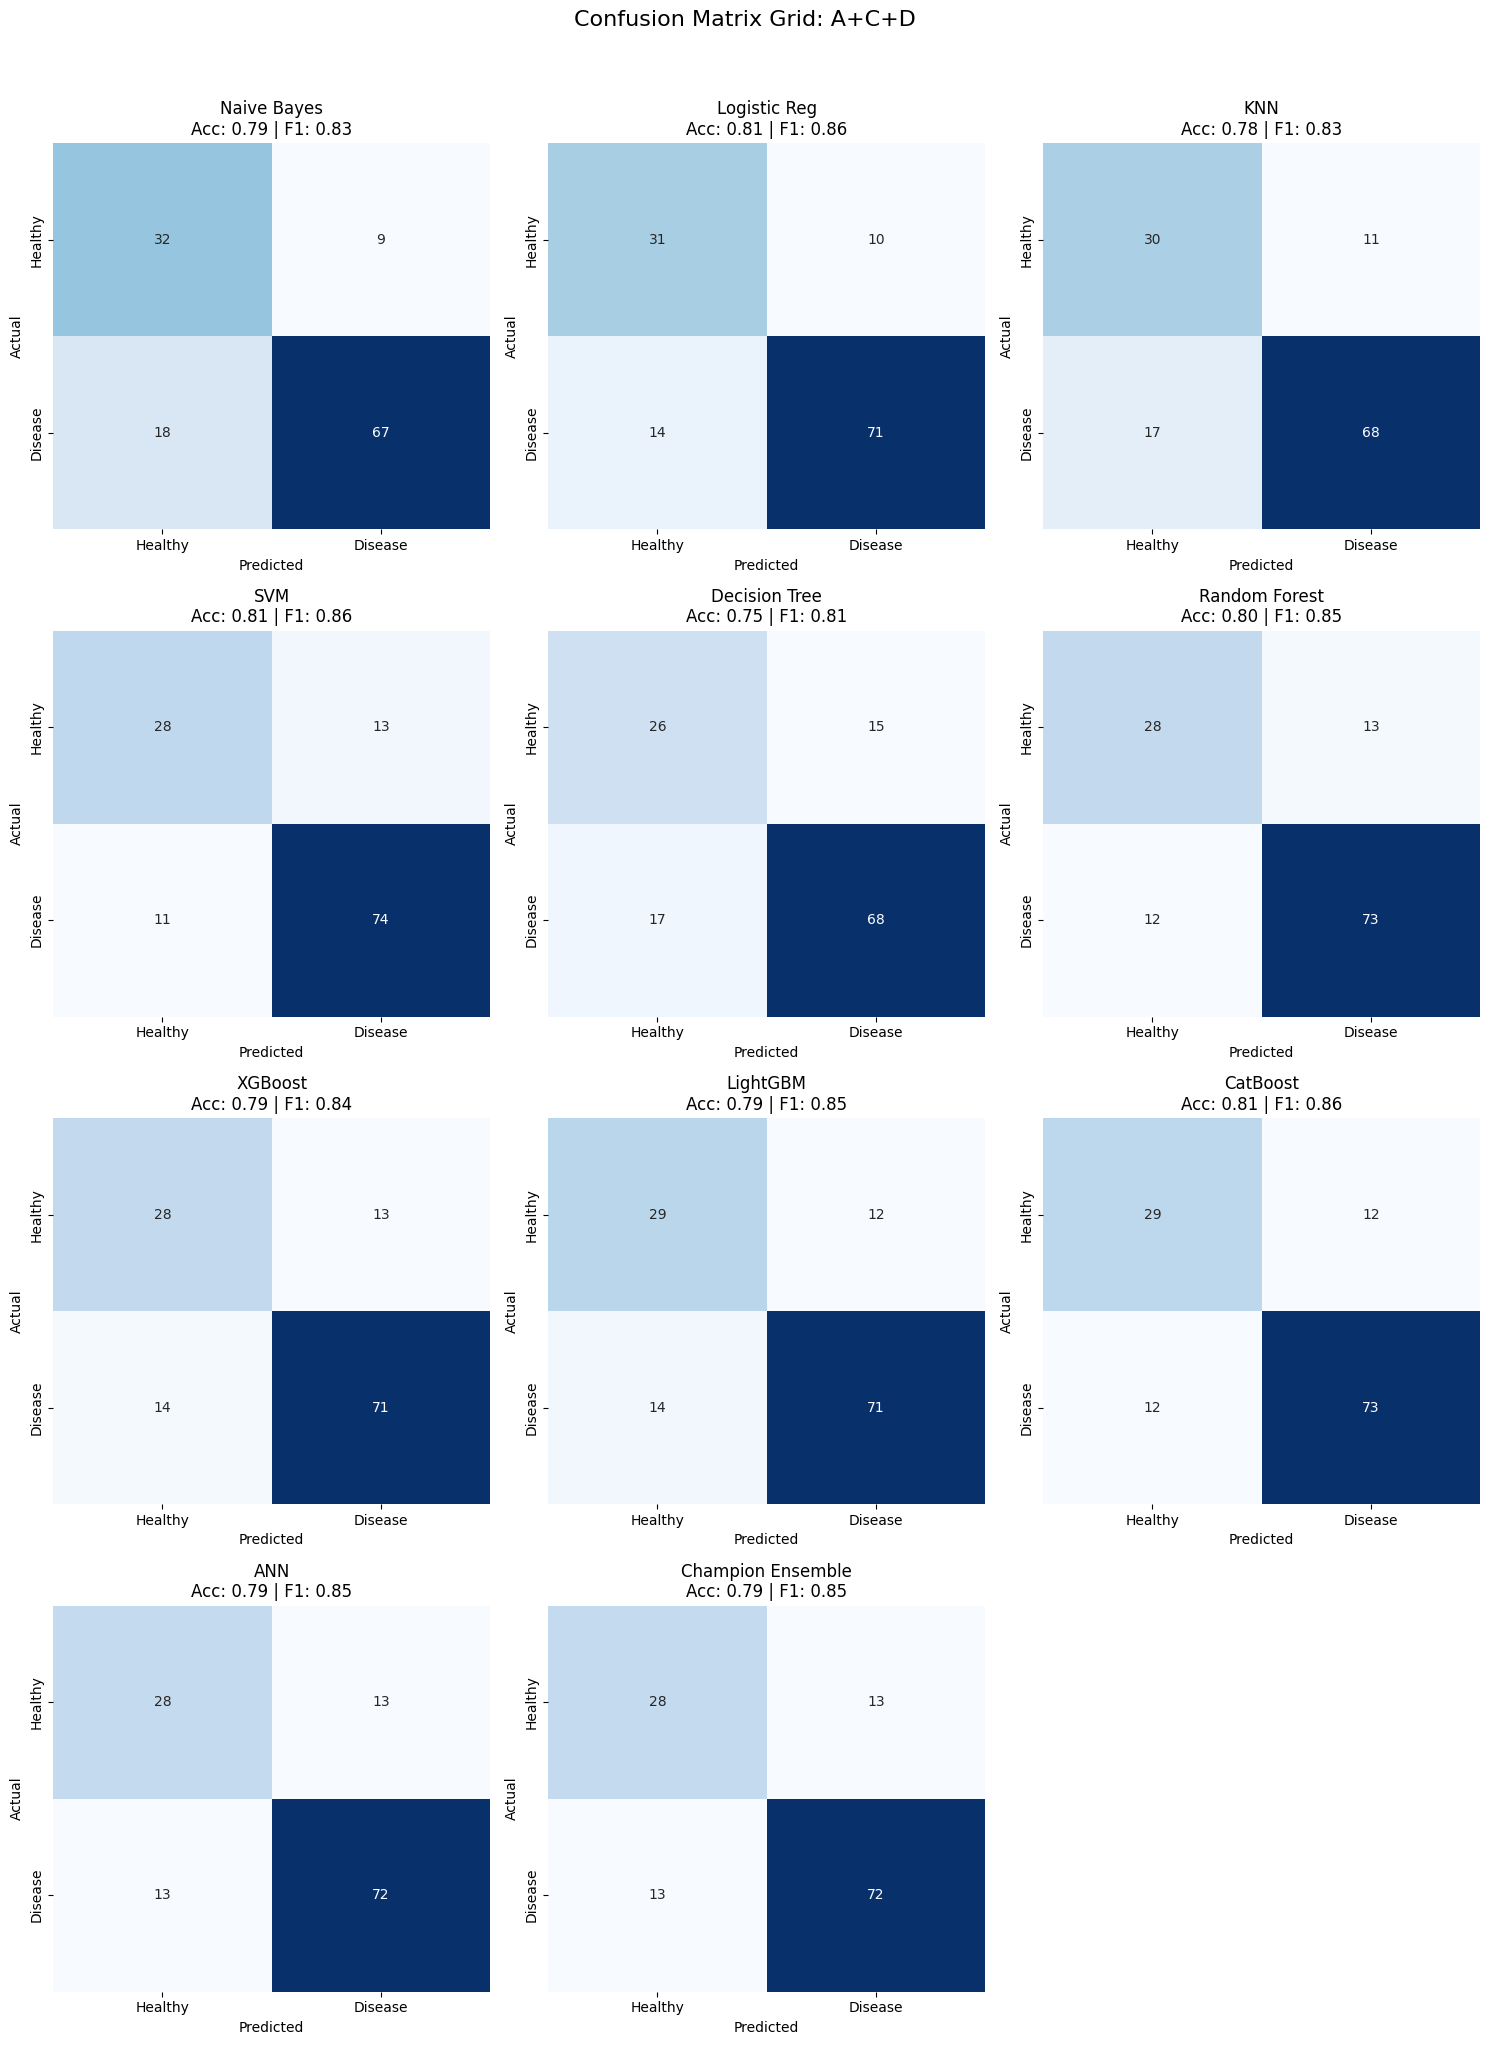


--- Error Analysis (A+C+D) ---


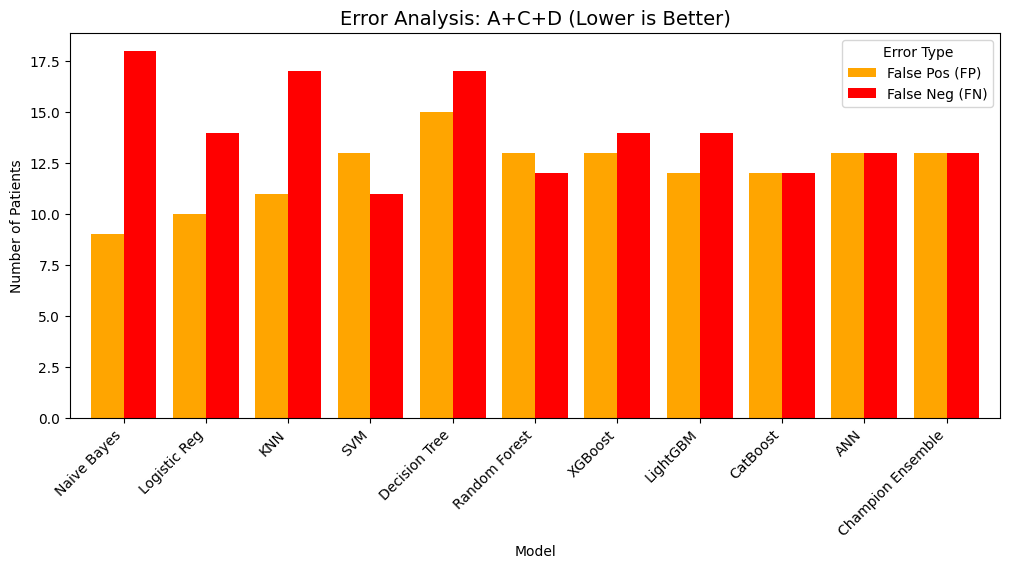




 RUNNING EXPERIMENT: DATASET [B+C+D]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:48:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: B+C+D (Samples: 617)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.766129,0.802721,36,14,15,59
Logistic Reg,0.758065,0.797297,35,15,15,59
KNN,0.774194,0.813333,35,15,13,61
SVM,0.790323,0.831169,34,16,10,64
Decision Tree,0.782258,0.813793,38,12,15,59
Random Forest,0.766129,0.807947,34,16,13,61
XGBoost,0.774194,0.813333,35,15,13,61
LightGBM,0.750000,0.791946,34,16,15,59
CatBoost,0.790323,0.826667,36,14,12,62



--- Confusion Matrix Grid (B+C+D) ---


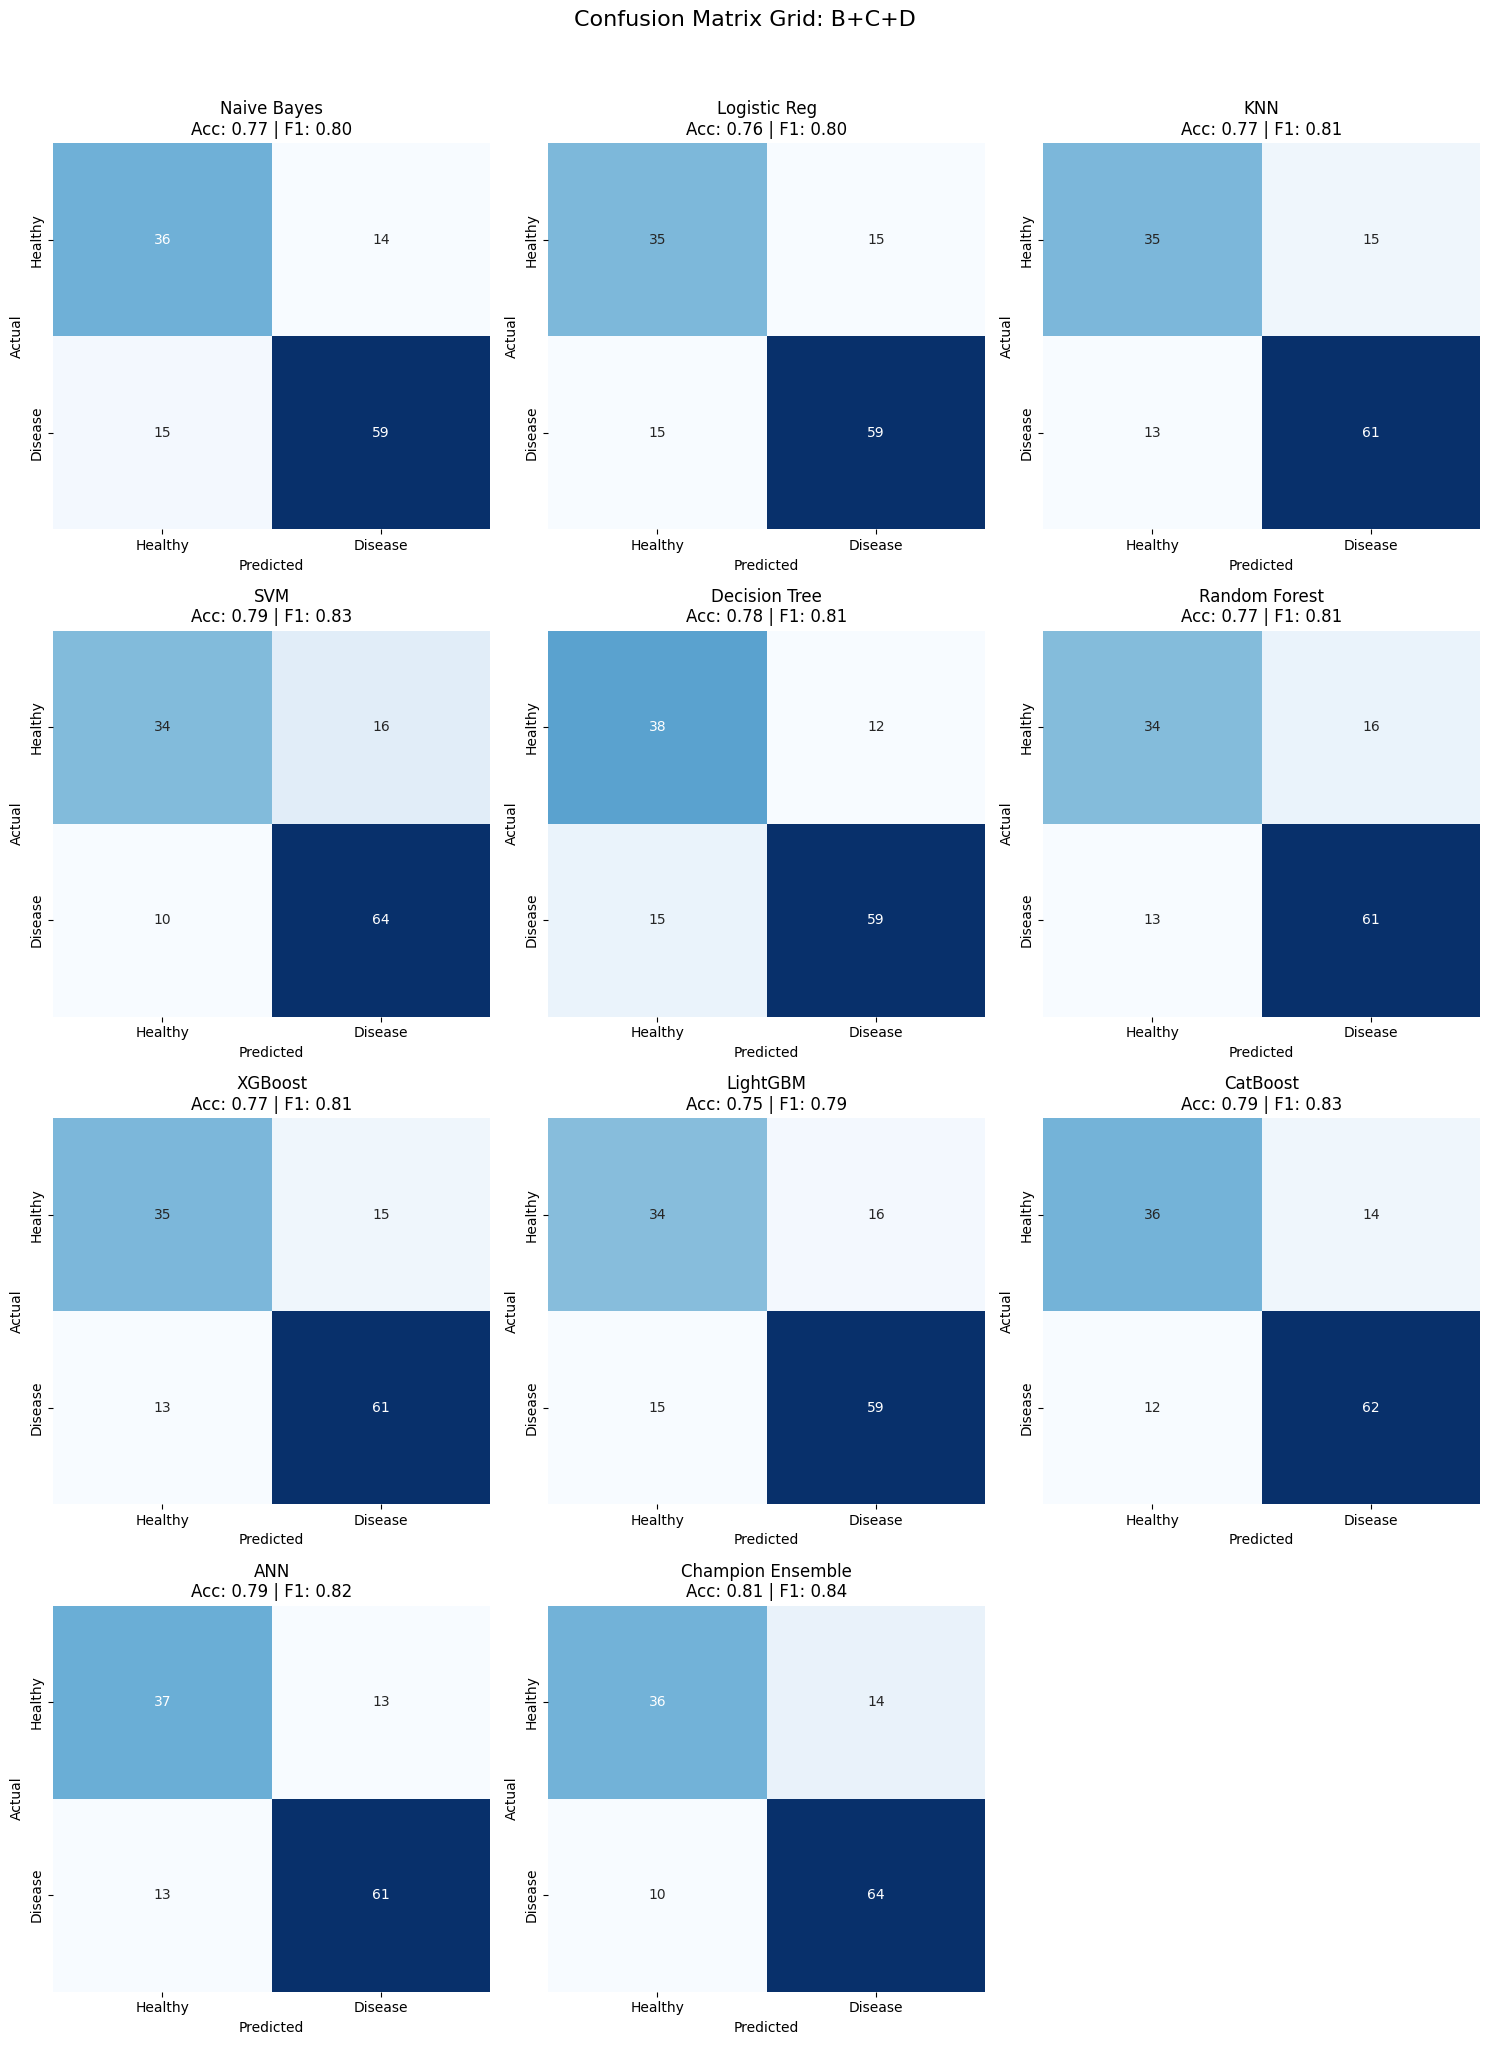


--- Error Analysis (B+C+D) ---


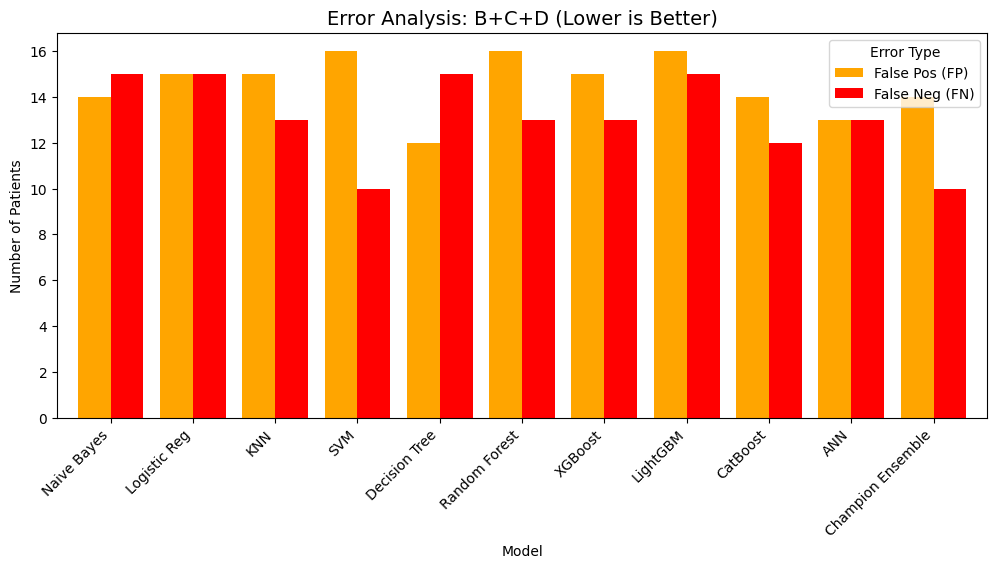




 RUNNING EXPERIMENT: DATASET [A+B+C+D]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:48:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



 RESULTS FOR DATASET: A+B+C+D (Samples: 920)


,Accuracy,F1-Score,True Neg,False Pos (FP),False Neg (FN),True Pos
Model,,,,,,
Naive Bayes,0.804348,0.825243,63,12,24,85
Logistic Reg,0.798913,0.821256,62,13,24,85
KNN,0.847826,0.866667,65,10,18,91
SVM,0.847826,0.865385,66,9,19,90
Decision Tree,0.831522,0.857143,60,15,16,93
Random Forest,0.847826,0.867925,64,11,17,92
XGBoost,0.842391,0.862559,64,11,18,91
LightGBM,0.836957,0.854369,66,9,21,88
CatBoost,0.842391,0.861244,65,10,19,90



--- Confusion Matrix Grid (A+B+C+D) ---


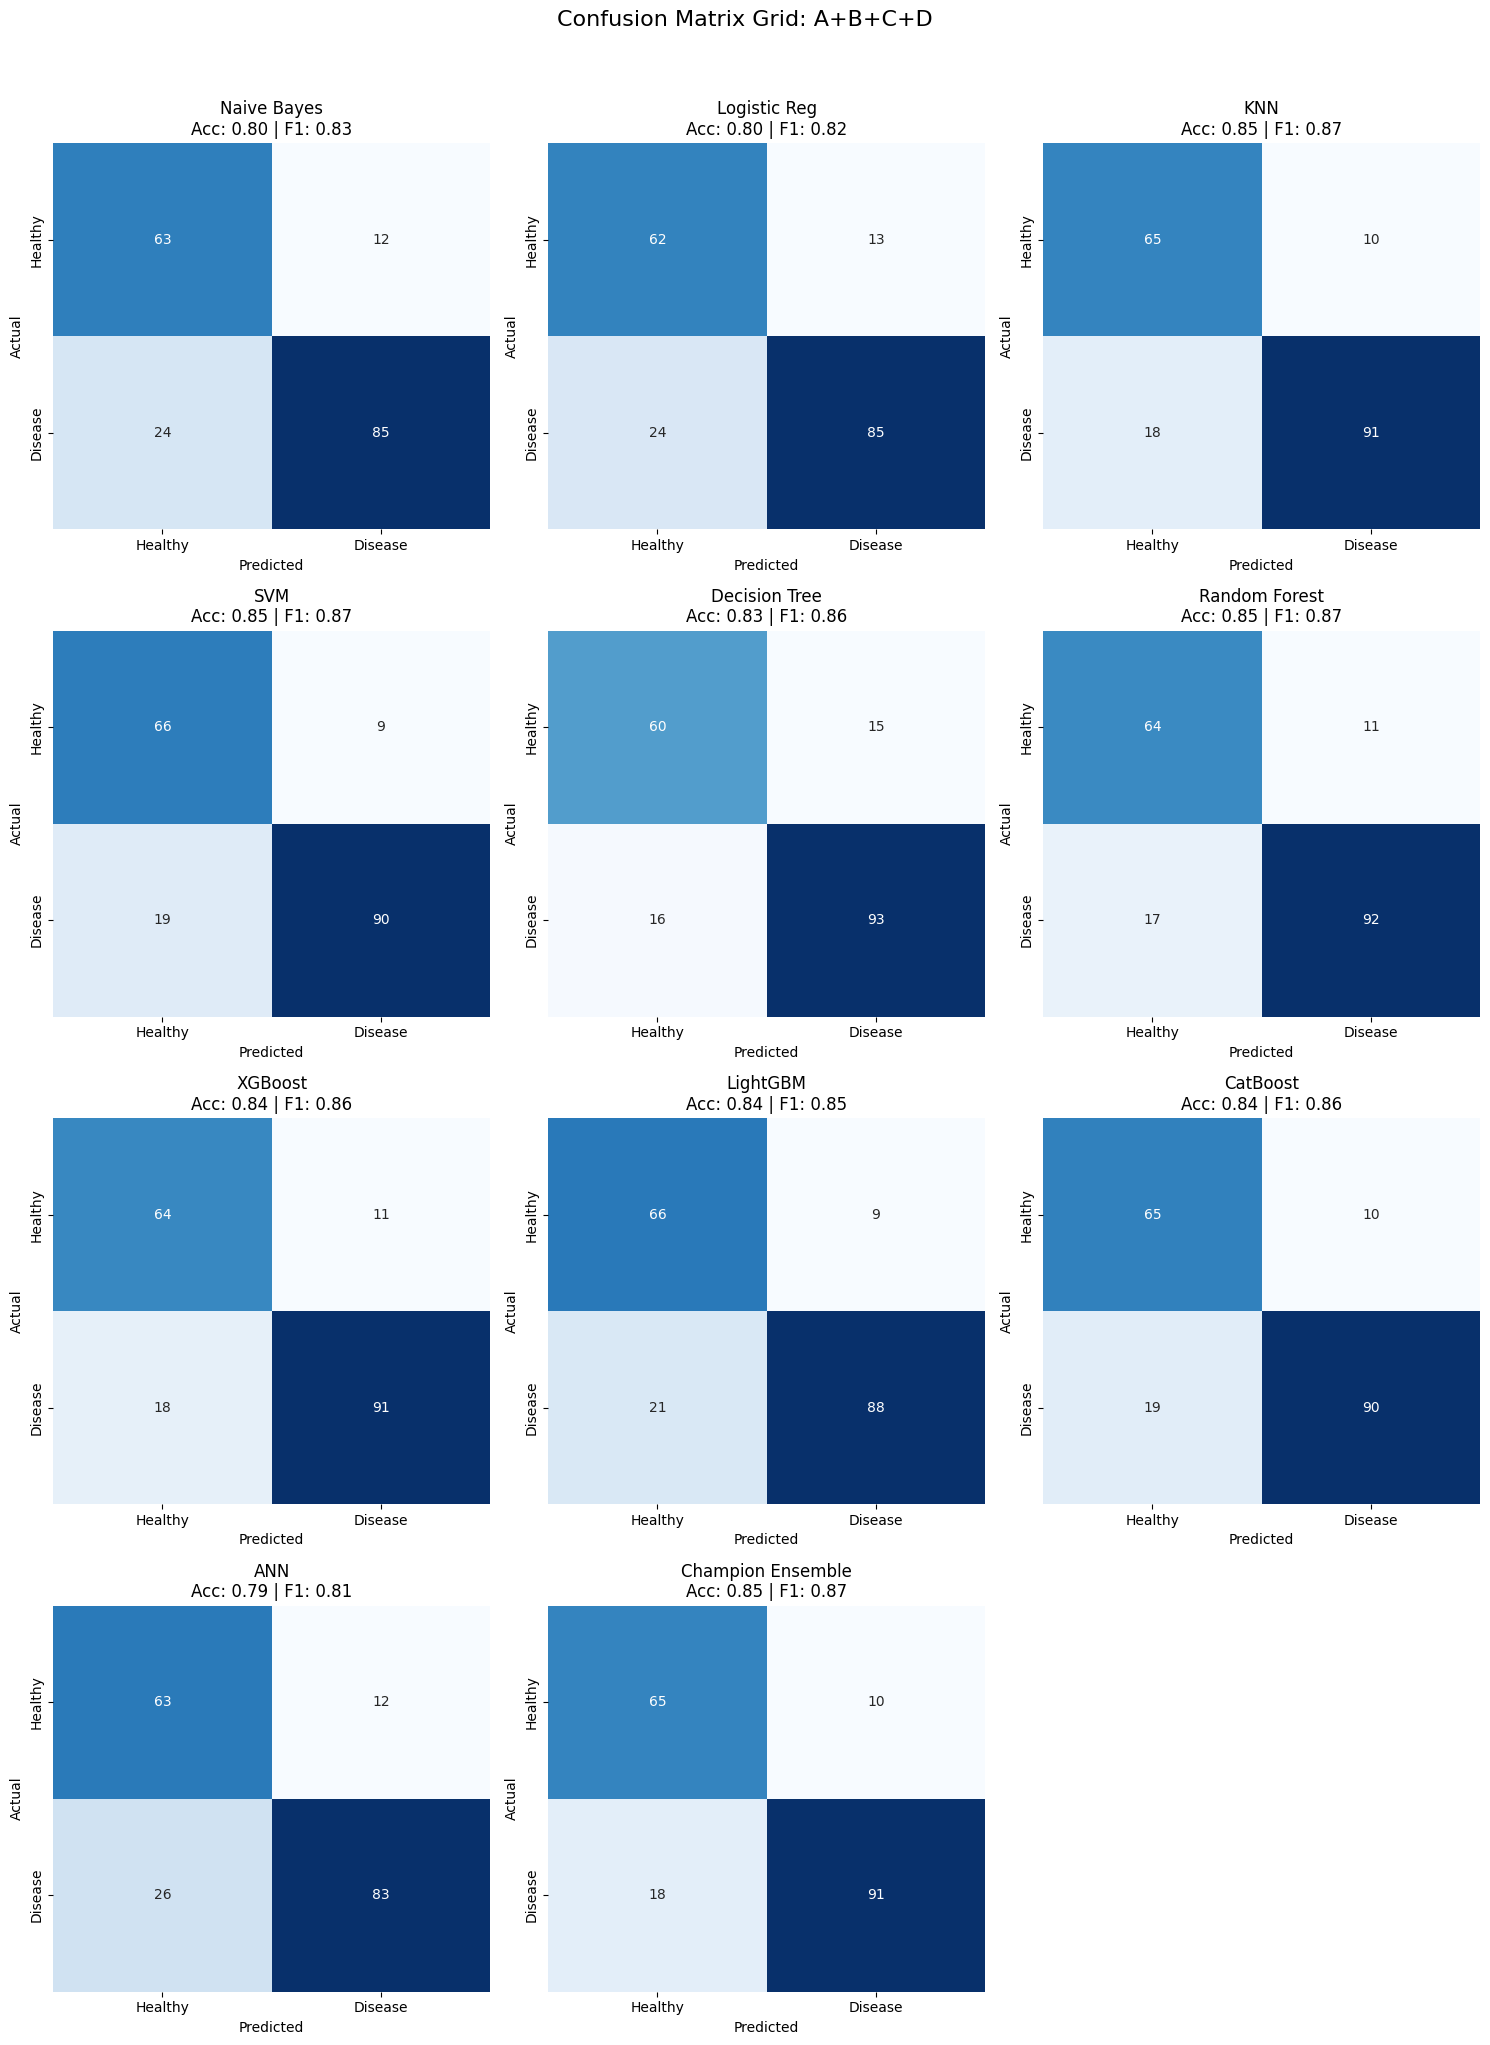


--- Error Analysis (A+B+C+D) ---


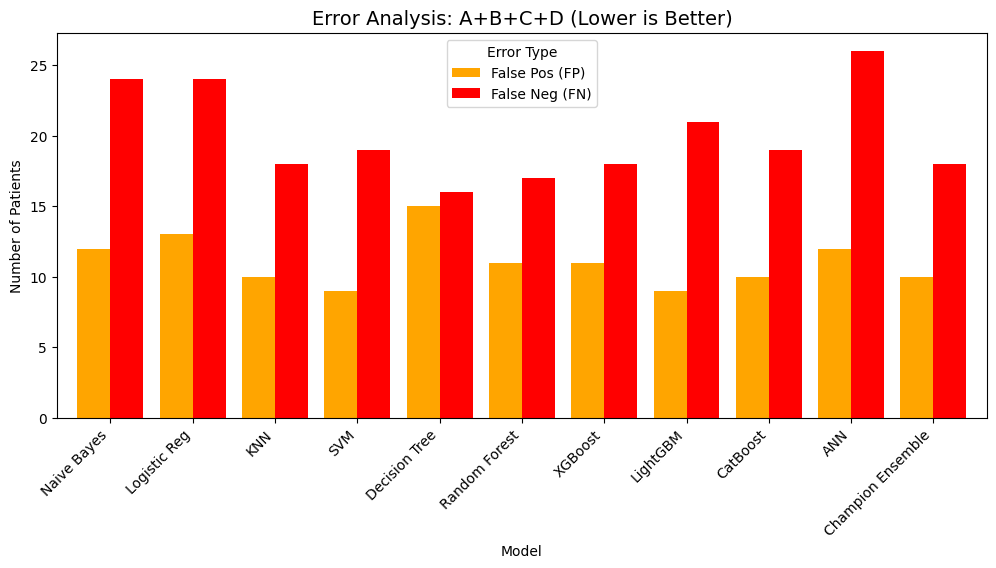




FINAL COMPLETION: ALL 15 DATASET COMBINATIONS ANALYZED.


In [3]:
# ==========================================================
# 3. EXECUTE PIPELINE ON ALL 15 COMBINATIONS
# ==========================================================

# Generate all combinations: A, B, AB, ABC...
combos = []
for r in range(1, 5):
    combos.extend(itertools.combinations(datasets.keys(), r))

print(f" STARTING EXPERIMENT ON {len(combos)} DATASET COMBINATIONS...\n")

# Loop through every combination
for combo in combos:
    combo_name = "+".join(combo)
    print("="*80)
    print(f" RUNNING EXPERIMENT: DATASET [{combo_name}]")
    print("="*80)

    # 1. MERGE DATA
    dfs_list = [datasets[k] for k in combo]
    df = pd.concat(dfs_list, axis=0, ignore_index=True)

    # 2. PREPROCESSING (Your Code)
    # Drop columns if they are 100% empty in this combo to prevent crash
    df = df.dropna(axis=1, how='all')

    X = df.drop('target', axis=1)
    y = df['target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

    # Impute & Scale
    imputer = KNNImputer(n_neighbors=5)
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp), columns=X.columns)
    X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp), columns=X.columns)

    # 3. DEFINE MODELS
    models = {
        "Naive Bayes": GaussianNB(),
        "Logistic Reg": LogisticRegression(max_iter=1000),
        "KNN": KNeighborsClassifier(n_neighbors=7),
        "SVM": SVC(probability=True, random_state=42),
        "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        "LightGBM": lgb.LGBMClassifier(random_state=42, verbosity=-1),
        "CatBoost": CatBoostClassifier(verbose=0, random_state=42)
    }

    results_store = {} # To store y_pred for visualization
    metrics_list = []  # To store metric values for table

    # 4. TRAIN & EVALUATE INDIVIDUAL MODELS
    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        results_store[name] = {'y_true': y_test, 'y_pred': y_pred, 'Accuracy': acc, 'F1': f1}
        metrics_list.append({
            "Model": name, "Accuracy": acc, "F1-Score": f1,
            "True Neg": tn, "False Pos (FP)": fp, "False Neg (FN)": fn, "True Pos": tp
        })

    # 5. TRAIN ANN
    ann = Sequential([Dense(16, activation='relu', input_dim=X_train_scaled.shape[1]),
                      Dense(8, activation='relu'), Dropout(0.1), Dense(1, activation='sigmoid')])
    ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    ann.fit(X_train_scaled, y_train, epochs=30, batch_size=16, verbose=0)
    y_pred_ann = (ann.predict(X_test_scaled, verbose=0) > 0.5).astype(int).flatten()

    acc_ann = accuracy_score(y_test, y_pred_ann)
    f1_ann = f1_score(y_test, y_pred_ann)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_ann).ravel()

    results_store["ANN"] = {'y_true': y_test, 'y_pred': y_pred_ann, 'Accuracy': acc_ann, 'F1': f1_ann}
    metrics_list.append({"Model": "ANN", "Accuracy": acc_ann, "F1-Score": f1_ann, "True Neg": tn, "False Pos (FP)": fp, "False Neg (FN)": fn, "True Pos": tp})

    # 6. TRAIN CHAMPION ENSEMBLE (Manual Strategy)
    svm_tuned = SVC(C=3.0, kernel='rbf', gamma='scale', probability=True, random_state=42)
    rf_tuned = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42)
    cat_tuned = CatBoostClassifier(verbose=0, depth=5, random_state=42)
    lr_tuned = LogisticRegression(C=0.5, solver='liblinear', random_state=42)

    champion = VotingClassifier(estimators=[('svm', svm_tuned), ('rf', rf_tuned), ('cat', cat_tuned), ('lr', lr_tuned)], voting='soft', weights=[3, 2, 3, 1])
    champion.fit(X_train_scaled, y_train)
    y_pred_champ = champion.predict(X_test_scaled)

    acc_champ = accuracy_score(y_test, y_pred_champ)
    f1_champ = f1_score(y_test, y_pred_champ)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_champ).ravel()

    results_store["Champion Ensemble"] = {'y_true': y_test, 'y_pred': y_pred_champ, 'Accuracy': acc_champ, 'F1': f1_champ}
    metrics_list.append({"Model": "Champion Ensemble", "Accuracy": acc_champ, "F1-Score": f1_champ, "True Neg": tn, "False Pos (FP)": fp, "False Neg (FN)": fn, "True Pos": tp})

    # --- OUTPUTS FOR THIS COMBINATION ---
    print(f"\n RESULTS FOR DATASET: {combo_name} (Samples: {len(df)})")

    # A. Comparison Table
    df_res = pd.DataFrame(metrics_list).set_index("Model")
    display(df_res.style.background_gradient(cmap='Greens', subset=['Accuracy', 'F1-Score']).background_gradient(cmap='Reds', subset=['False Neg (FN)']))

    # B. Confusion Matrix Grid
    print(f"\n--- Confusion Matrix Grid ({combo_name}) ---")
    plot_confusion_matrix_grid(results_store, combo_name)

    # C. Error Analysis Plot
    print(f"\n--- Error Analysis ({combo_name}) ---")
    plot_error_analysis(df_res, combo_name)

    print("\n\n")

print("FINAL COMPLETION: ALL 15 DATASET COMBINATIONS ANALYZED.")